# **Protecting Salem’s Ecosystem: Predictive Modeling of Tree Canopies and Stream Temperatures**


## *RQ #1: Can we use historic stream temperature data to predict stream temperature for 2020, 2022, and 2024?*

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/Capstone ML Colab Datasets

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Capstone ML Colab Datasets


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, KFold, cross_validate
from sklearn.linear_model import LinearRegression, ElasticNet, BayesianRidge
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
!pip install catboost
from catboost import CatBoostRegressor
from sklearn.ensemble import VotingRegressor
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
! pip install plotnine
from plotnine import ggplot, aes, geom_point, labs, scale_color_manual,theme_minimal

In [ ]:
mic3 = pd.read_csv("mic3.csv")
mic12 = pd.read_csv("mic12.csv")

mic3['site'] = 'mic3'
mic12['site'] = 'mic12'

df = pd.concat([mic3, mic12])
df.head()

,year_num,month_num,season,start_date,end_date,median_temp_c,site
0,2016,1,Winter,2016-01-02,2016-01-31,7.873958,mic3
1,2016,2,Winter,2016-02-01,2016-02-29,9.147684,mic3
2,2016,3,Spring,2016-03-01,2016-03-31,10.140313,mic3
3,2016,4,Spring,2016-04-01,2016-04-30,13.157813,mic3
4,2016,5,Spring,2016-05-01,2016-05-31,15.526667,mic3


### 2020 model with combined sites

In [ ]:
scaler = MinMaxScaler()
df2020 = df[df['year_num'] == 2020]
X = df2020[['year_num','site',"month_num", "season"]]
y = df2020["median_temp_c"]


feature_preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), ['month_num', 'year_num']),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), ['season', 'site'])
    ]
)
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42)
svr = SVR()
en = ElasticNet()
br = BayesianRidge()
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
cat = CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, verbose=0, random_seed=42)
voting_regressor = VotingRegressor(estimators=[
    ('lr', lr),
    ('rf', rf),
    ('svr', svr),
    ('en', en),
    ('br',br),
    ('xgb',xgb),
    ('cat',cat)
])
# add neural network


models = [lr,rf,svr,en,br,xgb, cat, voting_regressor]
name_list=[]
rmse_list=[]
mae_list=[]
r2_list=[]
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for model in models:
    feature_pipeline = Pipeline(steps=[
        ('preprocessor', feature_preprocessor),
        ('model', model)
    ])

    full_pipeline = TransformedTargetRegressor(
        regressor=feature_pipeline,
        transformer=MinMaxScaler()
    )

    cv_results = cross_validate(
        full_pipeline, X, y, cv=kf,
        scoring=['neg_mean_squared_error', 'neg_mean_absolute_error', 'r2']
    )

    rmse_scores = np.sqrt(-cv_results['test_neg_mean_squared_error'])
    mae_scores = -cv_results['test_neg_mean_absolute_error']
    r2_scores = cv_results['test_r2']
    name_list.append(model.__class__.__name__)
    rmse_list.append(np.mean(rmse_scores))
    mae_list.append(np.mean(mae_scores))
    r2_list.append(np.mean(r2_scores))
    print(model.__class__.__name__)
    print("RMSE: ", np.mean(rmse_scores))
    print("MAE: ", np.mean(mae_scores))
    print("R^2: ", np.mean(r2_scores))
    #print(y_test, "pred:", pred)
    print("")
print(f"Names {name_list}, RMSE {rmse_list}")

LinearRegression
RMSE:  2.1200357701274455
MAE:  1.7270244935043206
R^2:  0.6855100524069687

RandomForestRegressor
RMSE:  1.17521835292967
MAE:  1.0319080979204178
R^2:  0.8833514127174651

SVR
RMSE:  2.4057971837327123
MAE:  1.9548420071019712
R^2:  0.6151494548147476

ElasticNet
RMSE:  4.255428220837978
MAE:  3.8299305609414818
R^2:  -0.1378563902797149

BayesianRidge
RMSE:  2.1218010449683833
MAE:  1.7330973943142243
R^2:  0.6863710975637394

XGBRegressor
RMSE:  1.2612805284802675
MAE:  0.9457605538486147
R^2:  0.831607920047389

CatBoostRegressor
RMSE:  1.3985370020059709
MAE:  1.2136059841521445
R^2:  0.8383643117399856

VotingRegressor
RMSE:  1.7162184661191557
MAE:  1.4929846459039657
R^2:  0.7973234136394296

Names ['LinearRegression', 'RandomForestRegressor', 'SVR', 'ElasticNet', 'BayesianRidge', 'XGBRegressor', 'CatBoostRegressor', 'VotingRegressor'], RMSE [np.float64(2.1200357701274455), np.float64(1.17521835292967), np.float64(2.4057971837327123), np.float64(4.255428220837

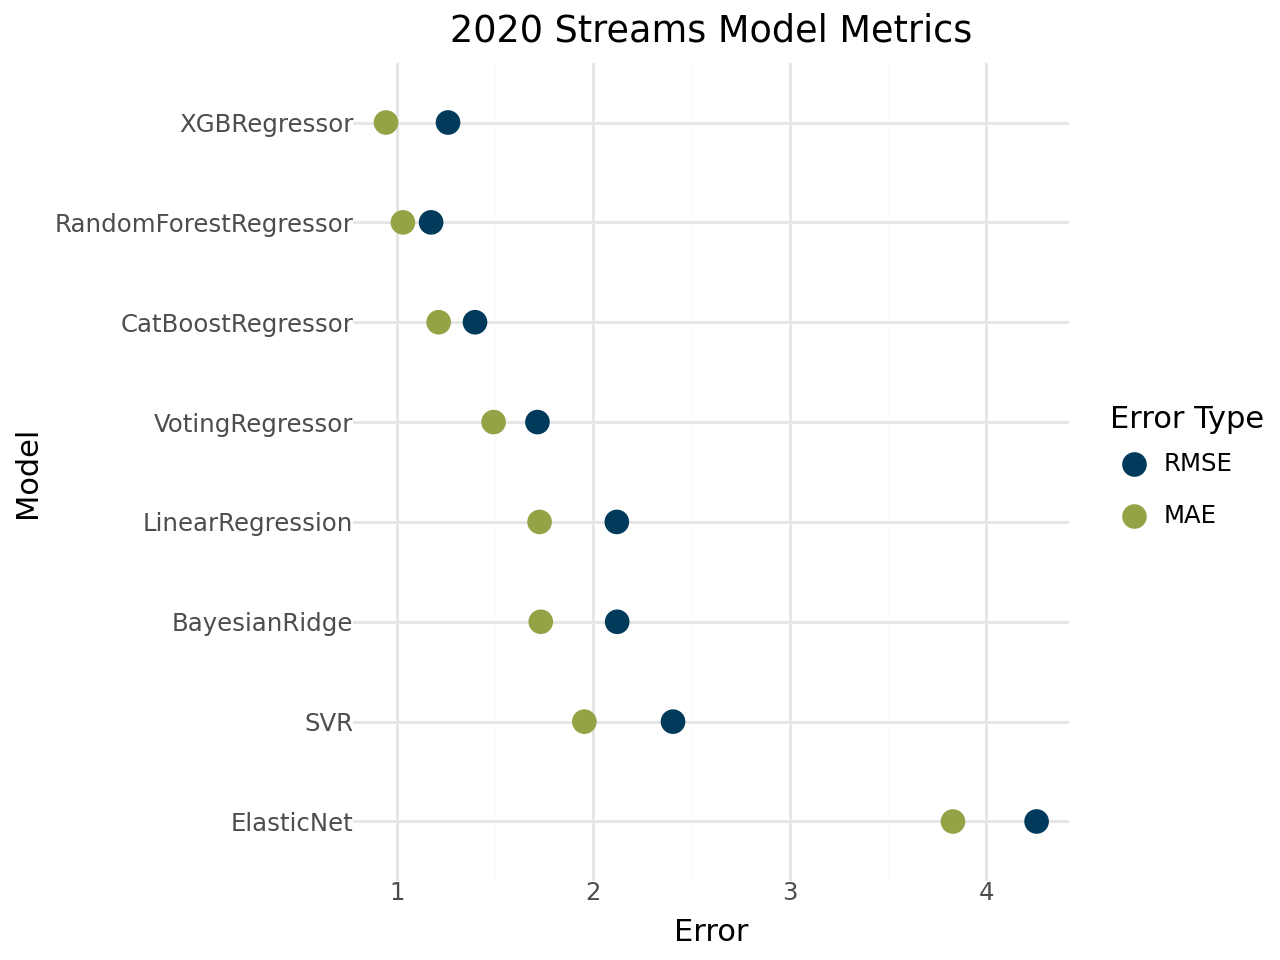

In [ ]:
dict={"Model": name_list,"RMSE":rmse_list,"MAE":mae_list,"R2":r2_list}
graphable=pd.DataFrame(dict)
long=pd.melt(graphable, id_vars=["Model"], value_vars=["RMSE", "MAE"])
order = graphable.sort_values(
    by = "RMSE", ascending = True)["Model"].tolist()
ggplot(long)+aes(x="value", y="reorder(Model, -value)",color="variable")+geom_point(size=4)+labs(x="Error",y="Model",title="2020 Streams Model Metrics")+scale_color_manual(
        name="Error Type",
        breaks=["RMSE", "MAE"],
        values=["#003b5c", "#95a346"],
    )+theme_minimal()

[Text(0.5, 0, 'Error'),
 Text(0, 0.5, 'Model Name'),
 Text(0.5, 1.0, '2020 Streams Model Metrics')]

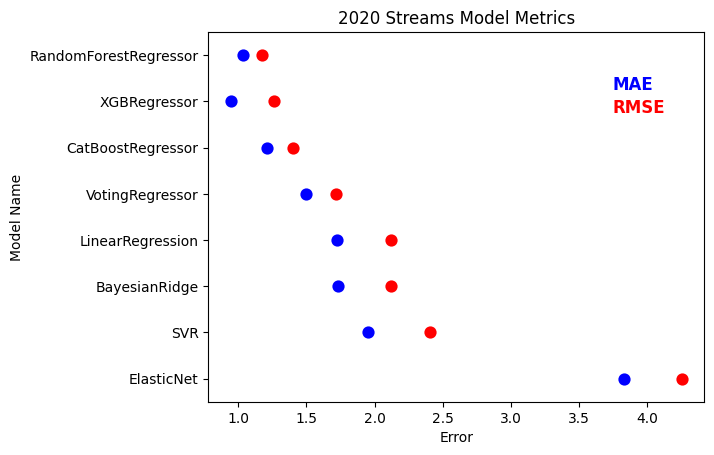

In [ ]:
dict={"Model": name_list,"RMSE":rmse_list,"MAE":mae_list,"R2":r2_list}
graphable=pd.DataFrame(dict)
order = graphable.sort_values(
    by = "RMSE", ascending = True)["Model"].tolist()
sns.pointplot(y = graphable["Model"] , x = graphable["RMSE"],order=order, linestyle='none', color="red")
plt=sns.pointplot(y=graphable["Model"], x=graphable["MAE"],order=order, linestyle='none', color='blue')
plt.text(x=3.75, y=1.25, s="RMSE", fontsize=12, color='red', weight='bold')
plt.text(x=3.75, y=.75, s="MAE", fontsize=12, color='blue', weight='bold')
plt.set(xlabel="Error",ylabel="Model Name",title="2020 Streams Model Metrics")


### 2022 Model with combined sites

In [ ]:
scaler = MinMaxScaler()
df2022 = df[df['year_num'] == 2022]
X = df2022[['year_num','site',"month_num", "season"]]
y = df2022["median_temp_c"]


feature_preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), ['month_num', 'year_num']),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), ['season', 'site'])
    ]
)
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42)
svr = SVR()
en = ElasticNet()
br = BayesianRidge()
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
cat = CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, verbose=0, random_seed=42)
voting_regressor = VotingRegressor(estimators=[
    ('lr', lr),
    ('rf', rf),
    ('svr', svr),
    ('en', en),
    ('br',br),
    ('xgb',xgb),
    ('cat',cat)
])

models = [lr,rf,svr,en,br,xgb, cat, voting_regressor]
name_list=[]
rmse_list=[]
mae_list=[]
r2_list=[]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for model in models:
    feature_pipeline = Pipeline(steps=[
        ('preprocessor', feature_preprocessor),
        ('model', model)
    ])

    full_pipeline = TransformedTargetRegressor(
        regressor=feature_pipeline,
        transformer=MinMaxScaler()
    )

    cv_results = cross_validate(
        full_pipeline, X, y, cv=kf,
        scoring=['neg_mean_squared_error', 'neg_mean_absolute_error', 'r2']
    )

    rmse_scores = np.sqrt(-cv_results['test_neg_mean_squared_error'])
    mae_scores = -cv_results['test_neg_mean_absolute_error']
    r2_scores = cv_results['test_r2']
    name_list.append(model.__class__.__name__)
    rmse_list.append(np.mean(rmse_scores))
    mae_list.append(np.mean(mae_scores))
    r2_list.append(np.mean(r2_scores))

    print(model.__class__.__name__)
    print("RMSE: ", np.mean(rmse_scores))
    print("MAE: ", np.mean(mae_scores))
    print("R^2: ", np.mean(r2_scores))
    print("")

LinearRegression
RMSE:  2.6743952173087817
MAE:  2.1297385083909592
R^2:  0.658343441570941

RandomForestRegressor
RMSE:  1.1967010951080934
MAE:  1.0016921974637651
R^2:  0.9257592689440435

SVR
RMSE:  2.8815540621748026
MAE:  2.573444112114554
R^2:  0.5898065053733053

ElasticNet
RMSE:  4.991746964503742
MAE:  4.468522441123188
R^2:  -0.43207550571725994

BayesianRidge
RMSE:  2.651849030484063
MAE:  2.2882384822258235
R^2:  0.6634882087159071

XGBRegressor
RMSE:  0.7191923964807222
MAE:  0.5068911643429083
R^2:  0.9072149261933233

CatBoostRegressor
RMSE:  1.4128267790403801
MAE:  1.1529611027577729
R^2:  0.8846423826146099

VotingRegressor
RMSE:  1.9256022112535292
MAE:  1.7495459944425253
R^2:  0.8170906498795446



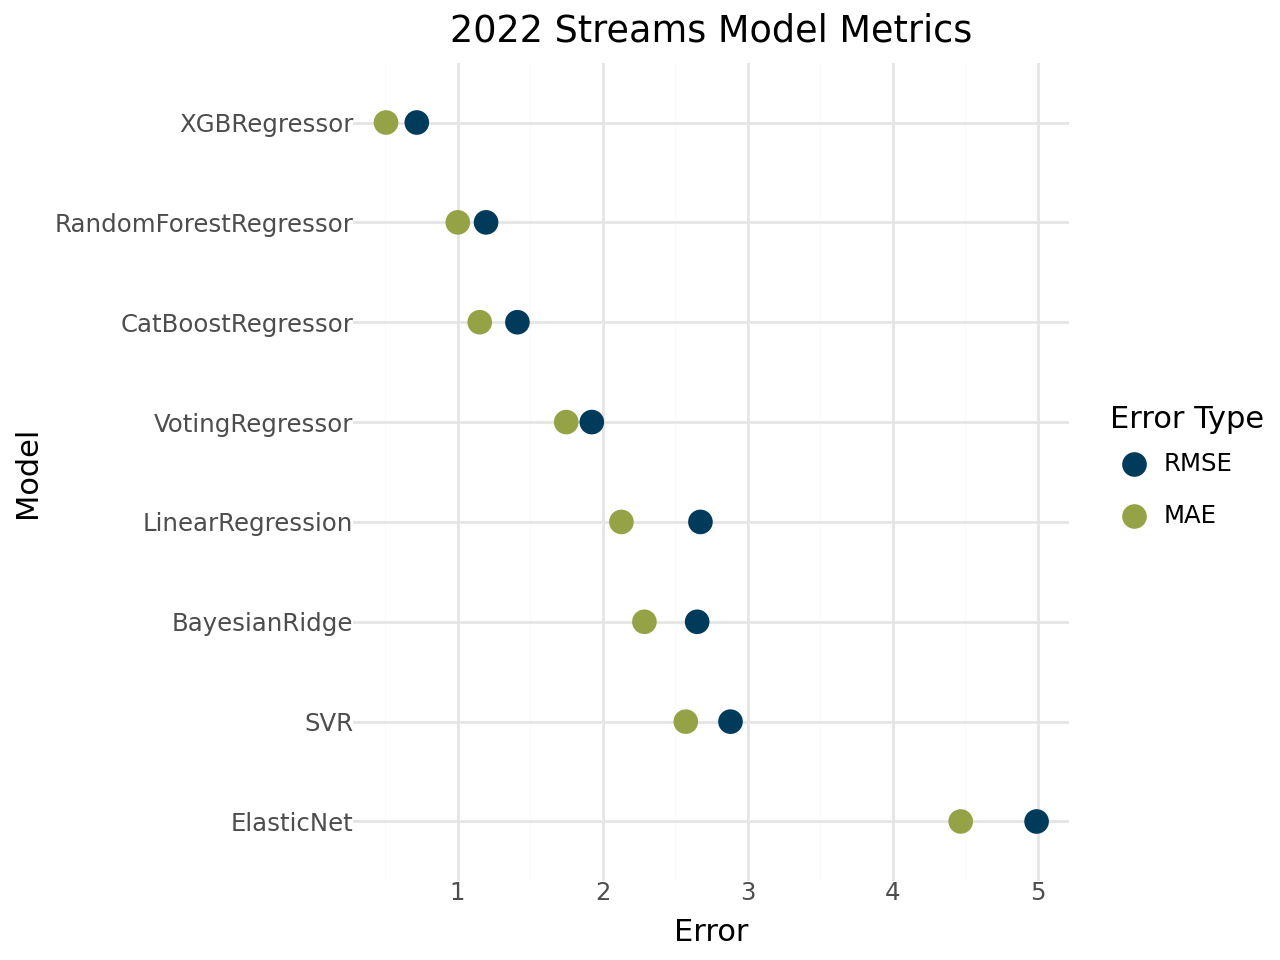

In [ ]:
dict={"Model": name_list,"RMSE":rmse_list,"MAE":mae_list,"R2":r2_list}
graphable=pd.DataFrame(dict)
long=pd.melt(graphable, id_vars=["Model"], value_vars=["RMSE", "MAE"])
order = graphable.sort_values(
    by = "RMSE", ascending = True)["Model"].tolist()
ggplot(long)+aes(x="value", y="reorder(Model, -value)",color="variable")+geom_point(size=4)+labs(x="Error",y="Model",title="2022 Streams Model Metrics")+scale_color_manual(
        name="Error Type",
        breaks=["RMSE", "MAE"],
        values=["#003b5c", "#95a346"],
    )+theme_minimal()

[Text(0.5, 0, 'Error'),
 Text(0, 0.5, 'Model Name'),
 Text(0.5, 1.0, '2022 Streams Model Metrics')]

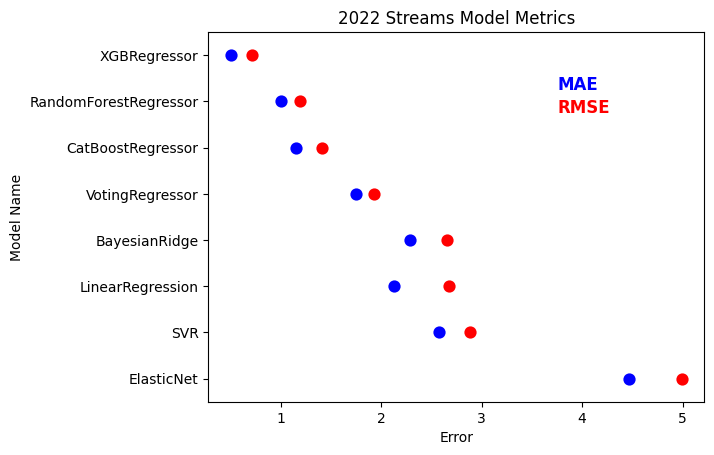

In [ ]:
dict={"Model": name_list,"RMSE":rmse_list,"MAE":mae_list,"R2":r2_list}
graphable=pd.DataFrame(dict)
order = graphable.sort_values(
    by = "RMSE", ascending = True)["Model"].tolist()
sns.pointplot(y = graphable["Model"] , x = graphable["RMSE"],order=order, linestyle='none', color="red")
plt=sns.pointplot(y=graphable["Model"], x=graphable["MAE"],order=order, linestyle='none', color='blue')
plt.text(x=3.75, y=1.25, s="RMSE", fontsize=12, color='red', weight='bold')
plt.text(x=3.75, y=.75, s="MAE", fontsize=12, color='blue', weight='bold')
plt.set(xlabel="Error",ylabel="Model Name",title="2022 Streams Model Metrics")

### 2024 Model with Combined Sites

In [ ]:
scaler = MinMaxScaler()
df2024 = df[df['year_num'] == 2024]
X = df2024[['year_num','site',"month_num", "season"]]
y = df2024["median_temp_c"]


feature_preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), ['month_num', 'year_num']),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), ['season', 'site'])
    ]
)
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42)
svr = SVR()
en = ElasticNet()
br = BayesianRidge()
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
cat = CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, verbose=0, random_seed=42)
voting_regressor = VotingRegressor(estimators=[
    ('lr', lr),
    ('rf', rf),
    ('svr', svr),
    ('en', en),
    ('br',br),
    ('xgb',xgb),
    ('cat',cat)
])

models = [lr,rf,svr,en,br,xgb, cat, voting_regressor]
name_list=[]
rmse_list=[]
mae_list=[]
r2_list=[]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for model in models:
    feature_pipeline = Pipeline(steps=[
        ('preprocessor', feature_preprocessor),
        ('model', model)
    ])

    full_pipeline = TransformedTargetRegressor(
        regressor=feature_pipeline,
        transformer=MinMaxScaler()
    )

    cv_results = cross_validate(
        full_pipeline, X, y, cv=kf,
        scoring=['neg_mean_squared_error', 'neg_mean_absolute_error', 'r2']
    )

    rmse_scores = np.sqrt(-cv_results['test_neg_mean_squared_error'])
    mae_scores = -cv_results['test_neg_mean_absolute_error']
    r2_scores = cv_results['test_r2']
    name_list.append(model.__class__.__name__)
    rmse_list.append(np.mean(rmse_scores))
    mae_list.append(np.mean(mae_scores))
    r2_list.append(np.mean(r2_scores))

    print(model.__class__.__name__)
    print("RMSE: ", np.mean(rmse_scores))
    print("MAE: ", np.mean(mae_scores))
    print("R^2: ", np.mean(r2_scores))
    print("")

LinearRegression
RMSE:  2.0456093306144725
MAE:  1.753546621096137
R^2:  0.7368569678031186

RandomForestRegressor
RMSE:  1.2896859900567859
MAE:  1.2032408084080948
R^2:  0.8713821941527188

SVR
RMSE:  2.5102019992527493
MAE:  2.2134054649099886
R^2:  0.6182980029563383

ElasticNet
RMSE:  4.492153273955088
MAE:  3.989187534311256
R^2:  -0.22683659273639445

BayesianRidge
RMSE:  2.0113778034432808
MAE:  1.7256667200284064
R^2:  0.7437420508705006

XGBRegressor
RMSE:  1.0840356192387097
MAE:  0.8134901141907427
R^2:  0.8115131268236884

CatBoostRegressor
RMSE:  1.5205660485681518
MAE:  1.3758834721301212
R^2:  0.8195351109619555

VotingRegressor
RMSE:  1.6946428512460634
MAE:  1.5299330096185355
R^2:  0.8140179942848722



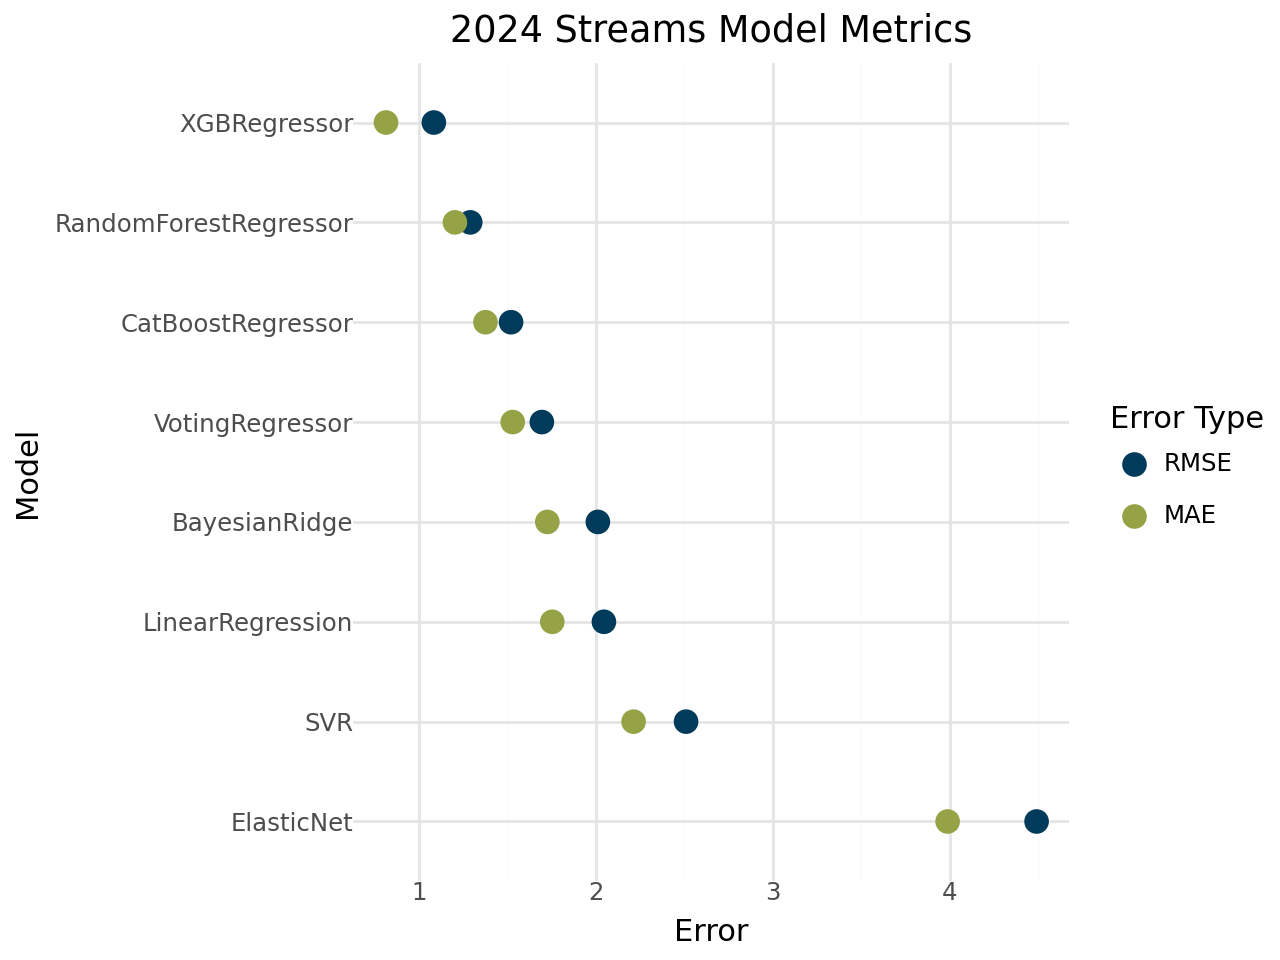

In [ ]:
dict={"Model": name_list,"RMSE":rmse_list,"MAE":mae_list,"R2":r2_list}
graphable=pd.DataFrame(dict)
long=pd.melt(graphable, id_vars=["Model"], value_vars=["RMSE", "MAE"])
order = graphable.sort_values(
    by = "RMSE", ascending = True)["Model"].tolist()
ggplot(long)+aes(x="value", y="reorder(Model, -value)",color="variable")+geom_point(size=4)+labs(x="Error",y="Model",title="2024 Streams Model Metrics")+scale_color_manual(
        name="Error Type",
        breaks=["RMSE", "MAE"],
        values=["#003b5c", "#95a346"],
    )+theme_minimal()

[Text(0.5, 0, 'Error'),
 Text(0, 0.5, 'Model Name'),
 Text(0.5, 1.0, '2024 Streams Model Metrics')]

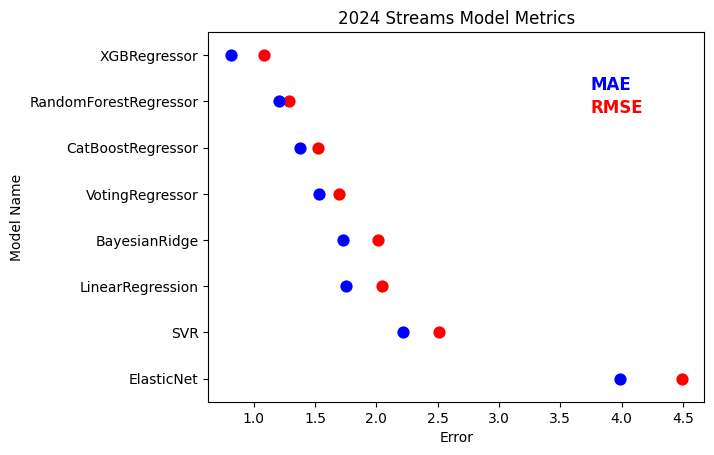

In [ ]:
dict={"Model": name_list,"RMSE":rmse_list,"MAE":mae_list,"R2":r2_list}
graphable=pd.DataFrame(dict)
order = graphable.sort_values(
    by = "RMSE", ascending = True)["Model"].tolist()
sns.pointplot(y = graphable["Model"] , x = graphable["RMSE"],order=order, linestyle='none', color="red")
plt=sns.pointplot(y=graphable["Model"], x=graphable["MAE"],order=order, linestyle='none', color='blue')
plt.text(x=3.75, y=1.25, s="RMSE", fontsize=12, color='red', weight='bold')
plt.text(x=3.75, y=.75, s="MAE", fontsize=12, color='blue', weight='bold')
plt.set(xlabel="Error",ylabel="Model Name",title="2024 Streams Model Metrics")

### All years and All Sites Model

In [ ]:
scaler = MinMaxScaler()
X = df[['year_num','site',"month_num", "season"]]
y = df["median_temp_c"]


feature_preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), ['month_num', 'year_num']),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), ['season', 'site'])
    ]
)
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42)
svr = SVR()
en = ElasticNet()
br = BayesianRidge()
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
cat = CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, verbose=0, random_seed=42)
voting_regressor = VotingRegressor(estimators=[
    ('lr', lr),
    ('rf', rf),
    ('svr', svr),
    ('en', en),
    ('br',br),
    ('xgb',xgb),
    ('cat',cat)
])


models = [lr,rf,svr,en,br,xgb, cat, voting_regressor]
name_list=[]
rmse_list=[]
mae_list=[]
r2_list=[]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for model in models:
    feature_pipeline = Pipeline(steps=[
        ('preprocessor', feature_preprocessor),
        ('model', model)
    ])

    full_pipeline = TransformedTargetRegressor(
        regressor=feature_pipeline,
        transformer=MinMaxScaler()
    )

    cv_results = cross_validate(
        full_pipeline, X, y, cv=kf,
        scoring=['neg_mean_squared_error', 'neg_mean_absolute_error', 'r2']
    )

    rmse_scores = np.sqrt(-cv_results['test_neg_mean_squared_error'])
    mae_scores = -cv_results['test_neg_mean_absolute_error']
    r2_scores = cv_results['test_r2']
    name_list.append(model.__class__.__name__)
    rmse_list.append(np.mean(rmse_scores))
    mae_list.append(np.mean(mae_scores))
    r2_list.append(np.mean(r2_scores))

    print(model.__class__.__name__)
    print("RMSE: ", np.mean(rmse_scores))
    print("MAE: ", np.mean(mae_scores))
    print("R^2: ", np.mean(r2_scores))
    print("")

LinearRegression
RMSE:  2.1315190990102133
MAE:  1.688380366614401
R^2:  0.7857484913828955

RandomForestRegressor
RMSE:  0.9391396149772161
MAE:  0.7130618225988838
R^2:  0.958785582961149

SVR
RMSE:  1.5581343542638333
MAE:  1.2377362917720731
R^2:  0.8864390221419672

ElasticNet
RMSE:  4.679152268440241
MAE:  4.106138600726036
R^2:  -0.017942214804709478

BayesianRidge
RMSE:  2.1311412476695137
MAE:  1.6873222695931662
R^2:  0.7858306104218808

XGBRegressor
RMSE:  0.8249169894404984
MAE:  0.5988095508086311
R^2:  0.9679693342300956

CatBoostRegressor
RMSE:  0.8939270211979625
MAE:  0.6823864210106193
R^2:  0.9627499866599079

VotingRegressor
RMSE:  1.4767724305316403
MAE:  1.2272461527434149
R^2:  0.8977282945616569



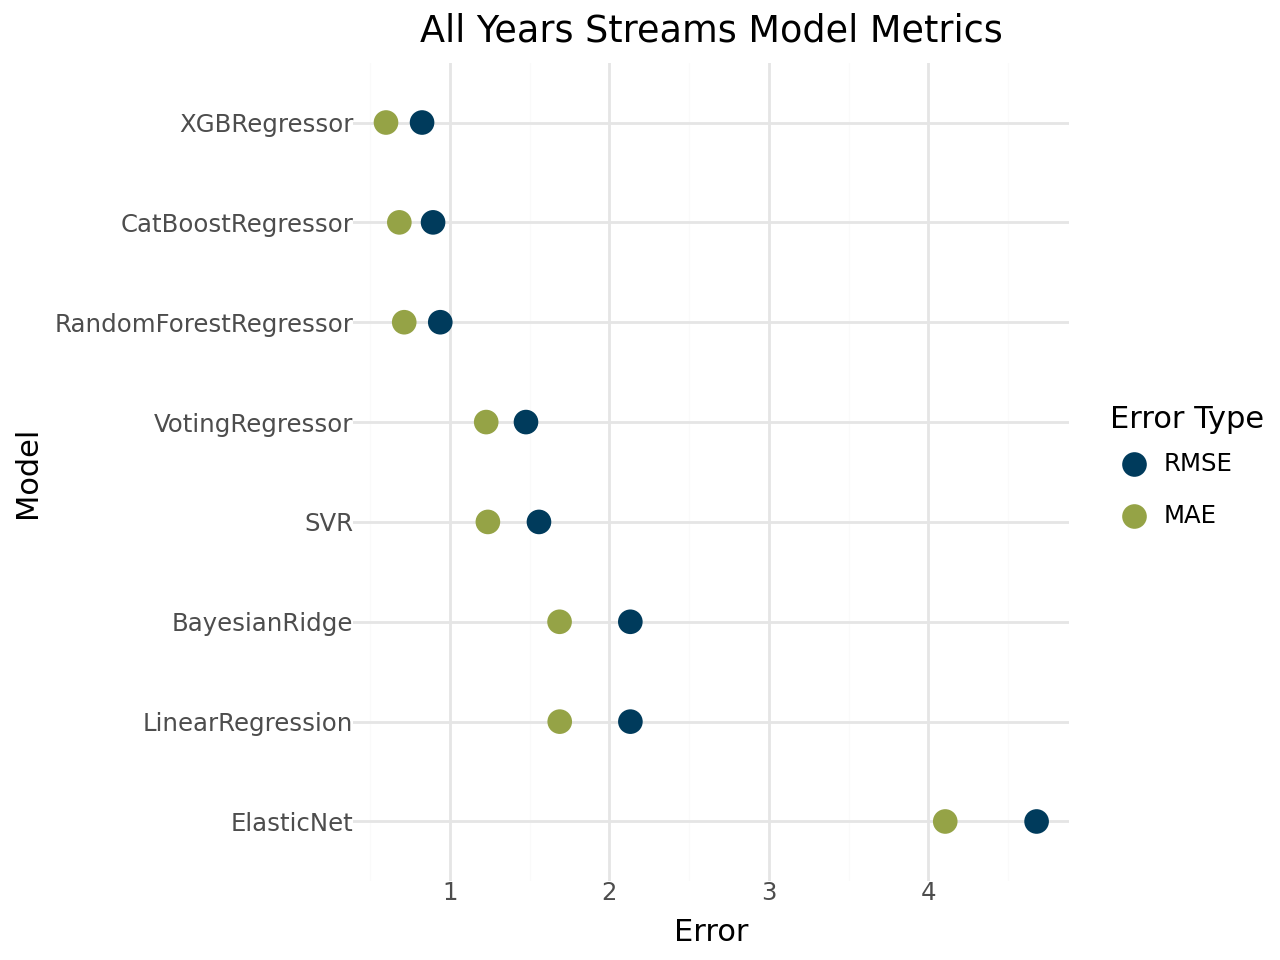

In [ ]:
dict={"Model": name_list,"RMSE":rmse_list,"MAE":mae_list,"R2":r2_list}
graphable=pd.DataFrame(dict)
long=pd.melt(graphable, id_vars=["Model"], value_vars=["RMSE", "MAE"])
order = graphable.sort_values(
    by = "RMSE", ascending = True)["Model"].tolist()
ggplot(long)+aes(x="value", y="reorder(Model, -value)",color="variable")+geom_point(size=4)+labs(x="Error",y="Model",title="All Years Streams Model Metrics")+scale_color_manual(
        name="Error Type",
        breaks=["RMSE", "MAE"],
        values=["#003b5c", "#95a346"],
    )+theme_minimal()

[Text(0.5, 0, 'Error'),
 Text(0, 0.5, 'Model Name'),
 Text(0.5, 1.0, 'All Years Streams Model Metrics')]

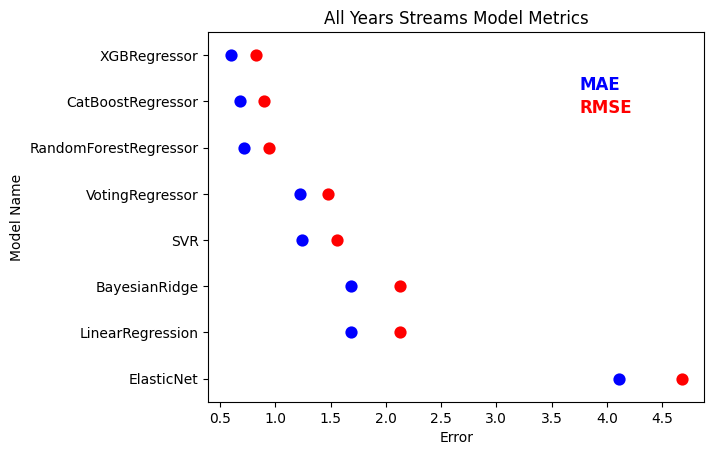

In [ ]:
dict={"Model": name_list,"RMSE":rmse_list,"MAE":mae_list,"R2":r2_list}
graphable=pd.DataFrame(dict)
order = graphable.sort_values(
    by = "RMSE", ascending = True)["Model"].tolist()
sns.pointplot(y = graphable["Model"] , x = graphable["RMSE"],order=order, linestyle='none', color="red")
plt=sns.pointplot(y=graphable["Model"], x=graphable["MAE"],order=order, linestyle='none', color='blue')
plt.text(x=3.75, y=1.25, s="RMSE", fontsize=12, color='red', weight='bold')
plt.text(x=3.75, y=.75, s="MAE", fontsize=12, color='blue', weight='bold')
plt.set(xlabel="Error",ylabel="Model Name",title="All Years Streams Model Metrics")

## *RQ #2: Can we combine historic stream and weather data to get a more accurate prediction of stream temperatures in 2020, 2022, and 2024?*


In [ ]:
#Reading in the weather data
weather=pd.read_csv("weather_temperature_salem.csv")

#filtering to get three datasets containing the correct years
weather2020=weather[weather['year_num']==2020]
weather2022=weather[weather['year_num']==2022]
weather2024=weather[weather['year_num']==2024]

#merging all three years with the stream data (df)
df2020_2 = pd.merge(df2020, weather2020, on=["start_date","year_num","month_num", "season", "end_date"])
df2022_2 = pd.merge(df2022, weather2022, on=["start_date","year_num","month_num", "season", "end_date"])
df2024_2 = pd.merge(df2024, weather2024, on=["start_date","year_num","month_num", "season", "end_date"])
df2024_2.head()

,year_num,month_num,season,start_date,end_date,median_temp_c,site,median_max_temp_f,median_precip
0,2024,1,Winter,2024-01-01,2024-01-31,7.883438,mic3,49.0,0.190
1,2024,2,Winter,2024-02-01,2024-02-29,8.848646,mic3,52.0,0.040
2,2024,3,Spring,2024-03-01,2024-03-31,9.833542,mic3,54.0,0.000
3,2024,4,Spring,2024-04-01,2024-04-30,12.912917,mic3,61.5,0.005
4,2024,5,Spring,2024-05-01,2024-05-31,14.580104,mic3,67.0,0.000


### 2020 Model with Combined Sites for Streams and Merged with Weather


In [ ]:
scaler = MinMaxScaler()
X = df2020_2[['year_num','site',"month_num", "season","median_max_temp_f","median_precip"]]
y = df2020_2["median_temp_c"]


feature_preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), ['month_num', 'year_num','median_max_temp_f','median_precip']),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), ['season', 'site'])
    ]
)
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42)
svr = SVR()
en = ElasticNet()
br = BayesianRidge()
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
cat = CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, verbose=0, random_seed=42)
voting_regressor = VotingRegressor(estimators=[
    ('lr', lr),
    ('rf', rf),
    ('svr', svr),
    ('en', en),
    ('br',br),
    ('xgb',xgb),
    ('cat',cat)
])


models = [lr,rf,svr,en,br,xgb, cat, voting_regressor]
name_list=[]
rmse_list=[]
mae_list=[]
r2_list=[]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for model in models:
    feature_pipeline = Pipeline(steps=[
        ('preprocessor', feature_preprocessor),
        ('model', model)
    ])

    full_pipeline = TransformedTargetRegressor(
        regressor=feature_pipeline,
        transformer=MinMaxScaler()
    )

    cv_results = cross_validate(
        full_pipeline, X, y, cv=kf,
        scoring=['neg_mean_squared_error', 'neg_mean_absolute_error', 'r2']
    )

    rmse_scores = np.sqrt(-cv_results['test_neg_mean_squared_error'])
    mae_scores = -cv_results['test_neg_mean_absolute_error']
    r2_scores = cv_results['test_r2']
    name_list.append(model.__class__.__name__)
    rmse_list.append(np.mean(rmse_scores))
    mae_list.append(np.mean(mae_scores))
    r2_list.append(np.mean(r2_scores))

    print(model.__class__.__name__)
    print("RMSE: ", np.mean(rmse_scores))
    print("MAE: ", np.mean(mae_scores))
    print("R^2: ", np.mean(r2_scores))
    print("")

LinearRegression
RMSE:  2.3376109721134366
MAE:  1.9262017016883894
R^2:  0.2523556638178538

RandomForestRegressor
RMSE:  0.8221939458218209
MAE:  0.6615744012709257
R^2:  0.9491758451641704

SVR
RMSE:  2.0957035367887777
MAE:  1.9386975269568136
R^2:  0.6806028827014652

ElasticNet
RMSE:  4.204249933131849
MAE:  3.8544350965882392
R^2:  -0.1684057722349101

BayesianRidge
RMSE:  1.7789860447297148
MAE:  1.4252783132613918
R^2:  0.6751261895656032

XGBRegressor
RMSE:  0.9076014104523142
MAE:  0.6805028049347637
R^2:  0.9400957058372352

CatBoostRegressor
RMSE:  1.2344742810306732
MAE:  1.1481844824406724
R^2:  0.8746842087773758

VotingRegressor
RMSE:  1.1293002135960037
MAE:  1.0209086595346095
R^2:  0.91221433230324



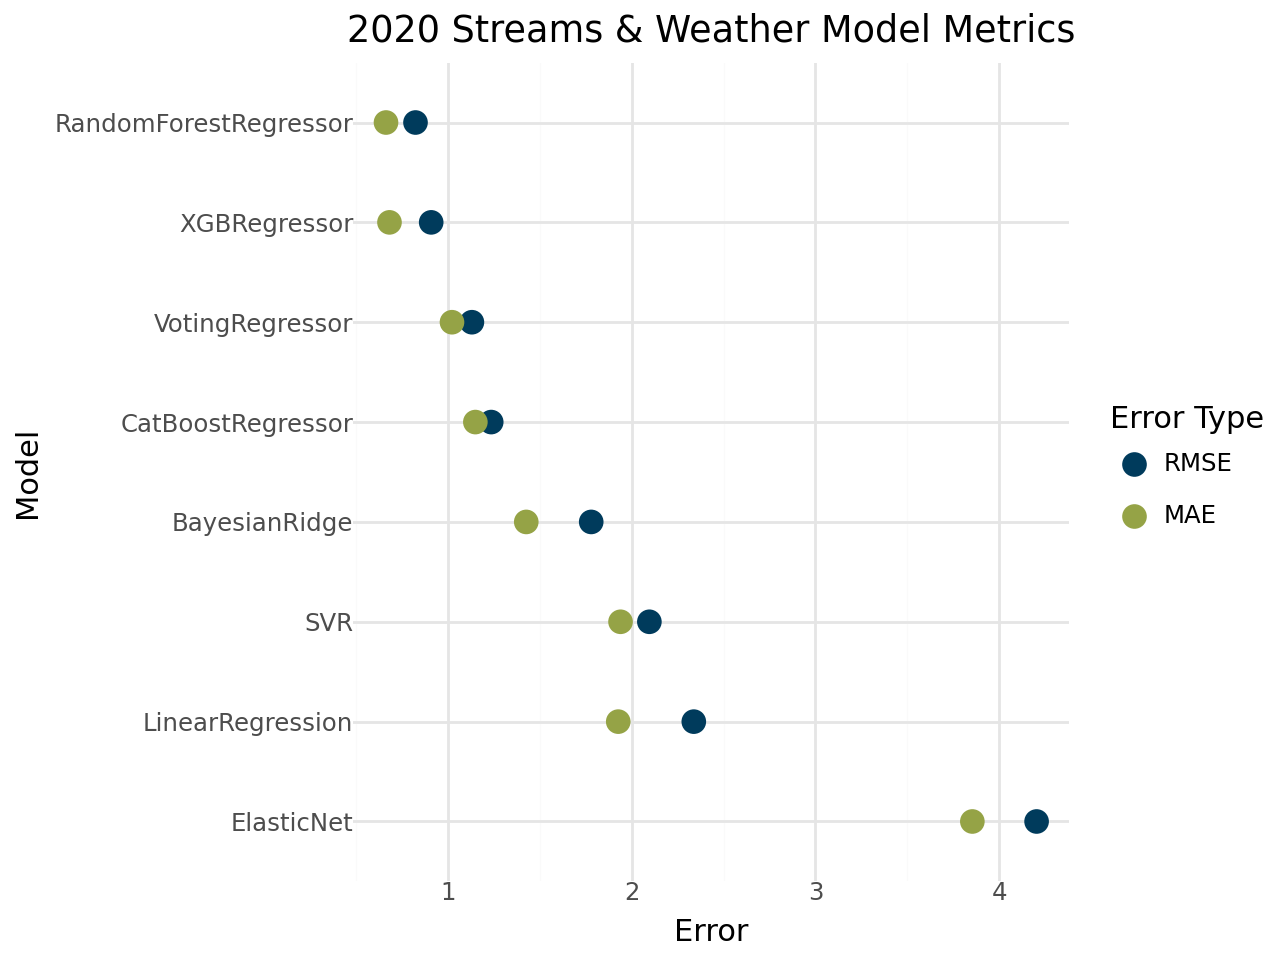

In [ ]:
dict={"Model": name_list,"RMSE":rmse_list,"MAE":mae_list,"R2":r2_list}
graphable=pd.DataFrame(dict)
long=pd.melt(graphable, id_vars=["Model"], value_vars=["RMSE", "MAE"])
order = graphable.sort_values(
    by = "RMSE", ascending = True)["Model"].tolist()
ggplot(long)+aes(x="value", y="reorder(Model, -value)",color="variable")+geom_point(size=4)+labs(x="Error",y="Model",title="2020 Streams & Weather Model Metrics")+scale_color_manual(
        name="Error Type",
        breaks=["RMSE", "MAE"],
        values=["#003b5c", "#95a346"],
    )+theme_minimal()

[Text(0.5, 0, 'Error'),
 Text(0, 0.5, 'Model Name'),
 Text(0.5, 1.0, '2020 Streams & Weather Model Metrics')]

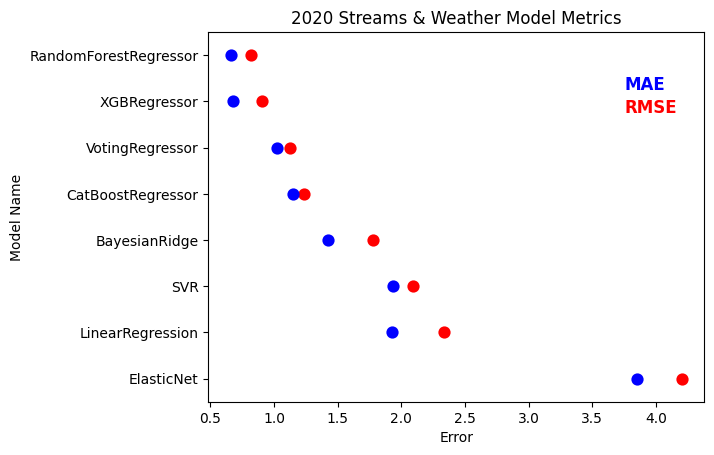

In [ ]:
dict={"Model": name_list,"RMSE":rmse_list,"MAE":mae_list,"R2":r2_list}
graphable=pd.DataFrame(dict)
order = graphable.sort_values(
    by = "RMSE", ascending = True)["Model"].tolist()
sns.pointplot(y = graphable["Model"] , x = graphable["RMSE"],order=order, linestyle='none', color="red")
plt=sns.pointplot(y=graphable["Model"], x=graphable["MAE"],order=order, linestyle='none', color='blue')
plt.text(x=3.75, y=1.25, s="RMSE", fontsize=12, color='red', weight='bold')
plt.text(x=3.75, y=.75, s="MAE", fontsize=12, color='blue', weight='bold')
plt.set(xlabel="Error",ylabel="Model Name",title="2020 Streams & Weather Model Metrics")

### 2022 Model with Combined Sites for Streams and Merged with Weather

In [ ]:
scaler = MinMaxScaler()
X = df2022_2[['year_num','site',"month_num", "season","median_max_temp_f","median_precip"]]
y = df2022_2["median_temp_c"]


feature_preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), ['month_num', 'year_num','median_max_temp_f','median_precip']),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), ['season', 'site'])
    ]
)
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42)
svr = SVR()
en = ElasticNet()
br = BayesianRidge()
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
cat = CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, verbose=0, random_seed=42)
voting_regressor = VotingRegressor(estimators=[
    ('lr', lr),
    ('rf', rf),
    ('svr', svr),
    ('en', en),
    ('br',br),
    ('xgb',xgb),
    ('cat',cat)
])
# add neural network


models = [lr,rf,svr,en,br,xgb, cat, voting_regressor]
name_list=[]
rmse_list=[]
mae_list=[]
r2_list=[]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for model in models:
    feature_pipeline = Pipeline(steps=[
        ('preprocessor', feature_preprocessor),
        ('model', model)
    ])

    full_pipeline = TransformedTargetRegressor(
        regressor=feature_pipeline,
        transformer=MinMaxScaler()
    )

    cv_results = cross_validate(
        full_pipeline, X, y, cv=kf,
        scoring=['neg_mean_squared_error', 'neg_mean_absolute_error', 'r2']
    )

    rmse_scores = np.sqrt(-cv_results['test_neg_mean_squared_error'])
    mae_scores = -cv_results['test_neg_mean_absolute_error']
    r2_scores = cv_results['test_r2']
    name_list.append(model.__class__.__name__)
    rmse_list.append(np.mean(rmse_scores))
    mae_list.append(np.mean(mae_scores))
    r2_list.append(np.mean(r2_scores))

    print(model.__class__.__name__)
    print("RMSE: ", np.mean(rmse_scores))
    print("MAE: ", np.mean(mae_scores))
    print("R^2: ", np.mean(r2_scores))
    print("")

LinearRegression
RMSE:  1.0629314940758625
MAE:  0.790224418099263
R^2:  0.34083222143735786

RandomForestRegressor
RMSE:  0.7963237284670031
MAE:  0.6444609495018083
R^2:  0.8918842471107459

SVR
RMSE:  1.773401532873283
MAE:  1.6518998340819704
R^2:  0.8085887177613073

ElasticNet
RMSE:  4.991746964503742
MAE:  4.468522441123188
R^2:  -0.43207550571725994

BayesianRidge
RMSE:  0.9475149537670816
MAE:  0.7155645939455354
R^2:  0.5217692375262536

XGBRegressor
RMSE:  0.7273203342091861
MAE:  0.5204497131264733
R^2:  0.6761248087197917

CatBoostRegressor
RMSE:  0.8253124844069923
MAE:  0.6690258802259195
R^2:  0.9645381891508867

VotingRegressor
RMSE:  1.1065503857807126
MAE:  1.0278660061630636
R^2:  0.9145267152532318



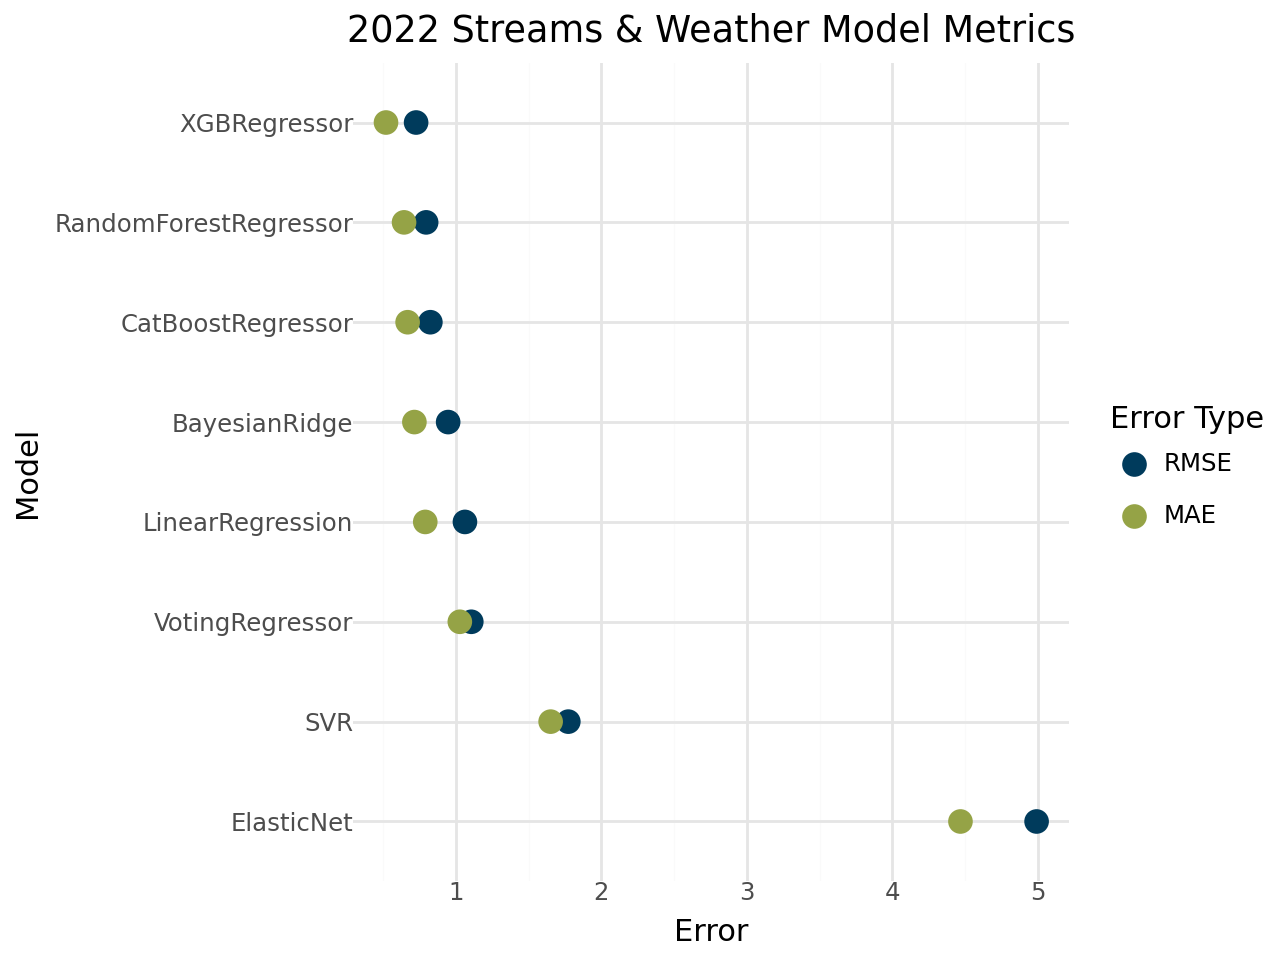

In [ ]:
dict={"Model": name_list,"RMSE":rmse_list,"MAE":mae_list,"R2":r2_list}
graphable=pd.DataFrame(dict)
long=pd.melt(graphable, id_vars=["Model"], value_vars=["RMSE", "MAE"])
order = graphable.sort_values(
    by = "RMSE", ascending = True)["Model"].tolist()
ggplot(long)+aes(x="value", y="reorder(Model, -value)",color="variable")+geom_point(size=4)+labs(x="Error",y="Model",title="2022 Streams & Weather Model Metrics")+scale_color_manual(
        name="Error Type",
        breaks=["RMSE", "MAE"],
        values=["#003b5c", "#95a346"],
    )+theme_minimal()

[Text(0.5, 0, 'Error'),
 Text(0, 0.5, 'Model Name'),
 Text(0.5, 1.0, '2022 Streams & Weather Model Metrics')]

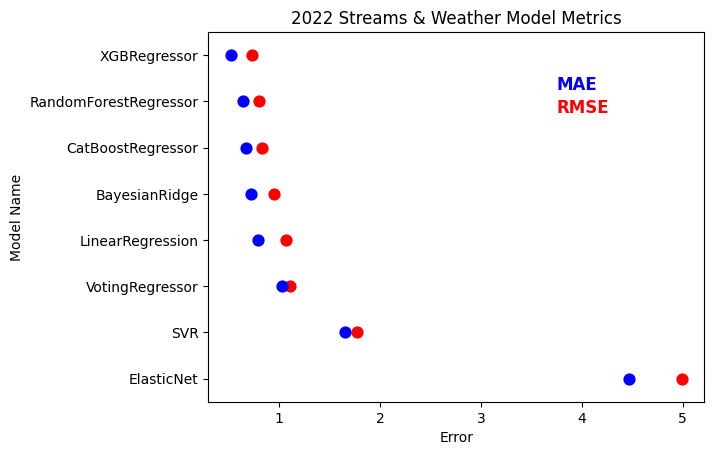

In [ ]:
dict={"Model": name_list,"RMSE":rmse_list,"MAE":mae_list,"R2":r2_list}
graphable=pd.DataFrame(dict)
order = graphable.sort_values(
    by = "RMSE", ascending = True)["Model"].tolist()
sns.pointplot(y = graphable["Model"] , x = graphable["RMSE"],order=order, linestyle='none', color="red")
plt=sns.pointplot(y=graphable["Model"], x=graphable["MAE"],order=order, linestyle='none', color='blue')
plt.text(x=3.75, y=1.25, s="RMSE", fontsize=12, color='red', weight='bold')
plt.text(x=3.75, y=.75, s="MAE", fontsize=12, color='blue', weight='bold')
plt.set(xlabel="Error",ylabel="Model Name",title="2022 Streams & Weather Model Metrics")

### 2024 Model with Combined Sites for Streams and Merged with Weather

In [ ]:
scaler = MinMaxScaler()
X = df2024_2[['year_num','site',"month_num", "season","median_max_temp_f","median_precip"]]
y = df2024_2["median_temp_c"]


feature_preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), ['month_num', 'year_num','median_max_temp_f','median_precip']),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), ['season', 'site'])
    ]
)
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42)
svr = SVR()
en = ElasticNet()
br = BayesianRidge()
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
cat = CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, verbose=0, random_seed=42)
voting_regressor = VotingRegressor(estimators=[
    ('lr', lr),
    ('rf', rf),
    ('svr', svr),
    ('en', en),
    ('br',br),
    ('xgb',xgb),
    ('cat',cat)
])

models = [lr,rf,svr,en,br,xgb, cat, voting_regressor]
name_list=[]
rmse_list=[]
mae_list=[]
r2_list=[]


kf = KFold(n_splits=5, shuffle=True, random_state=42)

for model in models:
    feature_pipeline = Pipeline(steps=[
        ('preprocessor', feature_preprocessor),
        ('model', model)
    ])

    full_pipeline = TransformedTargetRegressor(
        regressor=feature_pipeline,
        transformer=MinMaxScaler()
    )

    cv_results = cross_validate(
        full_pipeline, X, y, cv=kf,
        scoring=['neg_mean_squared_error', 'neg_mean_absolute_error', 'r2']
    )

    rmse_scores = np.sqrt(-cv_results['test_neg_mean_squared_error'])
    mae_scores = -cv_results['test_neg_mean_absolute_error']
    r2_scores = cv_results['test_r2']
    name_list.append(model.__class__.__name__)
    rmse_list.append(np.mean(rmse_scores))
    mae_list.append(np.mean(mae_scores))
    r2_list.append(np.mean(r2_scores))

    print(model.__class__.__name__)
    print("RMSE: ", np.mean(rmse_scores))
    print("MAE: ", np.mean(mae_scores))
    print("R^2: ", np.mean(r2_scores))
    print("")

LinearRegression
RMSE:  0.8281038610671626
MAE:  0.7352782612016394
R^2:  0.9492416201303856

RandomForestRegressor
RMSE:  0.8575614303842215
MAE:  0.7088169027113237
R^2:  0.9586079081146789

SVR
RMSE:  2.312762772556623
MAE:  2.1111009594326076
R^2:  0.69722914482192

ElasticNet
RMSE:  4.738273597381685
MAE:  4.2069432957086335
R^2:  -0.23758660383983732

BayesianRidge
RMSE:  0.7655483343558787
MAE:  0.6863189569552816
R^2:  0.958219827985873

XGBRegressor
RMSE:  0.7532131243616389
MAE:  0.545386694973546
R^2:  0.9602426568227106

CatBoostRegressor
RMSE:  1.5215669057996766
MAE:  1.2920394448980752
R^2:  0.8669832896642229

VotingRegressor
RMSE:  1.3858643690866743
MAE:  1.225924496695686
R^2:  0.8924858244047786



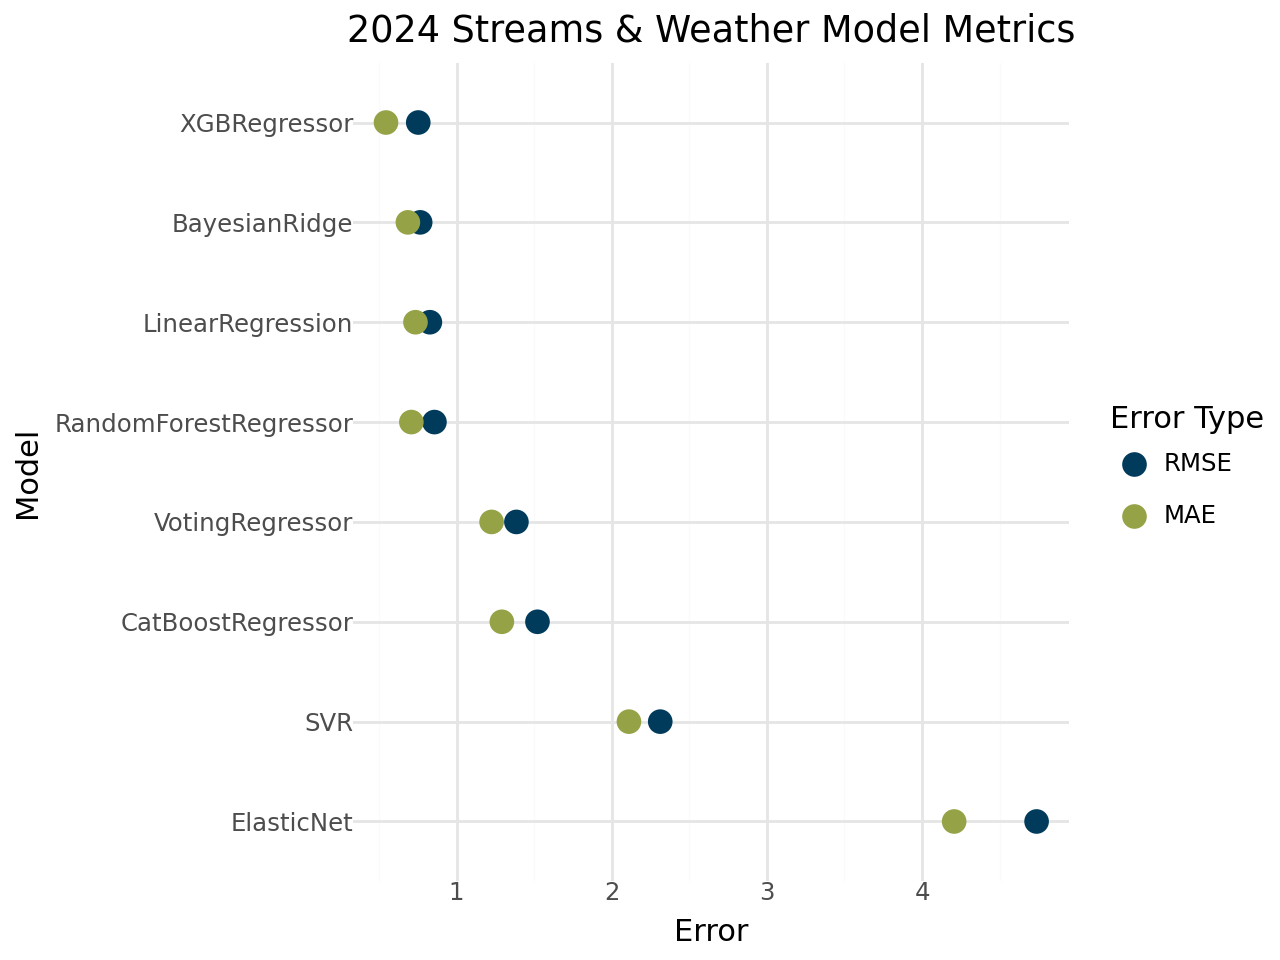

In [ ]:
dict={"Model": name_list,"RMSE":rmse_list,"MAE":mae_list,"R2":r2_list}
graphable=pd.DataFrame(dict)
long=pd.melt(graphable, id_vars=["Model"], value_vars=["RMSE", "MAE"])
order = graphable.sort_values(
    by = "RMSE", ascending = True)["Model"].tolist()
ggplot(long)+aes(x="value", y="reorder(Model, -value)",color="variable")+geom_point(size=4)+labs(x="Error",y="Model",title="2024 Streams & Weather Model Metrics")+scale_color_manual(
        name="Error Type",
        breaks=["RMSE", "MAE"],
        values=["#003b5c", "#95a346"],
    )+theme_minimal()

[Text(0.5, 0, 'Error'),
 Text(0, 0.5, 'Model Name'),
 Text(0.5, 1.0, '2024 Streams & Weather Model Metrics')]

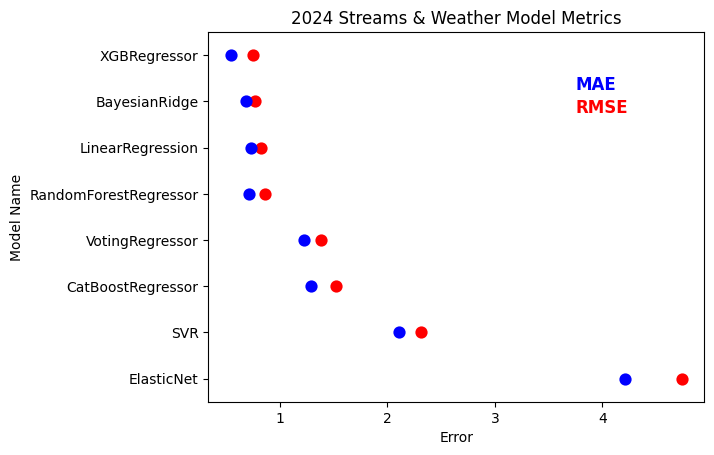

In [ ]:
dict={"Model": name_list,"RMSE":rmse_list,"MAE":mae_list,"R2":r2_list}
graphable=pd.DataFrame(dict)
order = graphable.sort_values(
    by = "RMSE", ascending = True)["Model"].tolist()
sns.pointplot(y = graphable["Model"] , x = graphable["RMSE"],order=order, linestyle='none', color="red")
plt=sns.pointplot(y=graphable["Model"], x=graphable["MAE"],order=order, linestyle='none', color='blue')
plt.text(x=3.75, y=1.25, s="RMSE", fontsize=12, color='red', weight='bold')
plt.text(x=3.75, y=.75, s="MAE", fontsize=12, color='blue', weight='bold')
plt.set(xlabel="Error",ylabel="Model Name",title="2024 Streams & Weather Model Metrics")

### All Years Model with Combined Sites for Streams and Merged with Weather

In [ ]:
#Reconnecting all three relevant years together for streams
dfall=pd.concat([df2020,df2022,df2024])

#Merging all years of weather and all years of streams together
weather_df_all=pd.merge(dfall,weather, on=["start_date","year_num","month_num", "season", "end_date"])

In [ ]:
scaler = MinMaxScaler()
X = weather_df_all[['year_num','site',"month_num", "season","median_max_temp_f","median_precip"]]
y = weather_df_all["median_temp_c"]


feature_preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), ['month_num', 'year_num','median_max_temp_f','median_precip']),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), ['season', 'site'])
    ]
)
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42)
svr = SVR()
en = ElasticNet()
br = BayesianRidge()
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
cat = CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, verbose=0, random_seed=42)
voting_regressor = VotingRegressor(estimators=[
    ('lr', lr),
    ('rf', rf),
    ('svr', svr),
    ('en', en),
    ('br',br),
    ('xgb',xgb),
    ('cat',cat)
])

models = [lr,rf,svr,en,br,xgb, cat, voting_regressor]
name_list=[]
rmse_list=[]
mae_list=[]
r2_list=[]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for model in models:
    feature_pipeline = Pipeline(steps=[
        ('preprocessor', feature_preprocessor),
        ('model', model)
    ])

    full_pipeline = TransformedTargetRegressor(
        regressor=feature_pipeline,
        transformer=MinMaxScaler()
    )

    cv_results = cross_validate(
        full_pipeline, X, y, cv=kf,
        scoring=['neg_mean_squared_error', 'neg_mean_absolute_error', 'r2']
    )

    rmse_scores = np.sqrt(-cv_results['test_neg_mean_squared_error'])
    mae_scores = -cv_results['test_neg_mean_absolute_error']
    r2_scores = cv_results['test_r2']
    name_list.append(model.__class__.__name__)
    rmse_list.append(np.mean(rmse_scores))
    mae_list.append(np.mean(mae_scores))
    r2_list.append(np.mean(r2_scores))

    print(model.__class__.__name__)
    print("RMSE: ", np.mean(rmse_scores))
    print("MAE: ", np.mean(mae_scores))
    print("R^2: ", np.mean(r2_scores))
    print("")

LinearRegression
RMSE:  0.6528156292070955
MAE:  0.5384067549848668
R^2:  0.9720811272918144

RandomForestRegressor
RMSE:  0.5606639473139268
MAE:  0.4420153656835872
R^2:  0.9833402843158641

SVR
RMSE:  1.6194548793984676
MAE:  1.4193928933235425
R^2:  0.8473744905909845

ElasticNet
RMSE:  4.703435770346856
MAE:  4.083272665006871
R^2:  -0.19101598084391974

BayesianRidge
RMSE:  0.6534799837077727
MAE:  0.5404898892978137
R^2:  0.9719918867681898

XGBRegressor
RMSE:  0.4422260351257967
MAE:  0.32716267000286287
R^2:  0.988239872599648

CatBoostRegressor
RMSE:  0.6271249642891458
MAE:  0.5163221844933277
R^2:  0.9759012812508192

VotingRegressor
RMSE:  1.0506747799166356
MAE:  0.9060236295293373
R^2:  0.9347136103372421



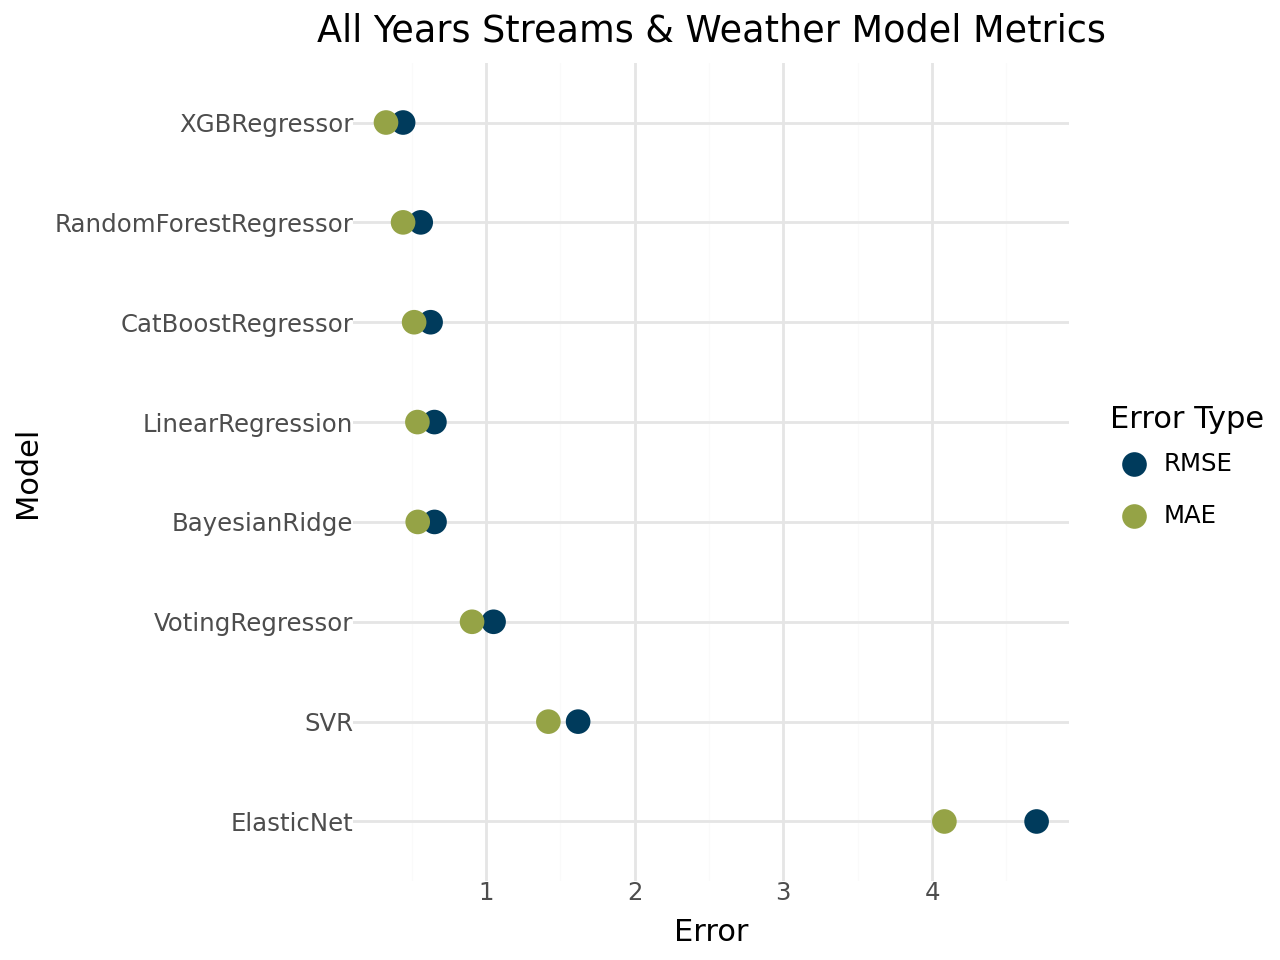

In [ ]:
dict={"Model": name_list,"RMSE":rmse_list,"MAE":mae_list,"R2":r2_list}
graphable=pd.DataFrame(dict)
long=pd.melt(graphable, id_vars=["Model"], value_vars=["RMSE", "MAE"])
order = graphable.sort_values(
    by = "RMSE", ascending = True)["Model"].tolist()
ggplot(long)+aes(x="value", y="reorder(Model, -value)",color="variable")+geom_point(size=4)+labs(x="Error",y="Model",title="All Years Streams & Weather Model Metrics")+scale_color_manual(
        name="Error Type",
        breaks=["RMSE", "MAE"],
        values=["#003b5c", "#95a346"],
    )+theme_minimal()

[Text(0.5, 0, 'Error'),
 Text(0, 0.5, 'Model Name'),
 Text(0.5, 1.0, 'All Years Streams & Weather Model Metrics')]

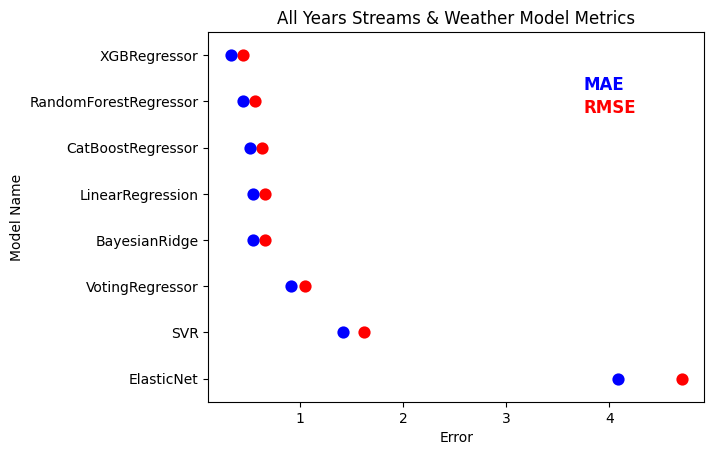

In [ ]:
dict={"Model": name_list,"RMSE":rmse_list,"MAE":mae_list,"R2":r2_list}
graphable=pd.DataFrame(dict)
order = graphable.sort_values(
    by = "RMSE", ascending = True)["Model"].tolist()
sns.pointplot(y = graphable["Model"] , x = graphable["RMSE"],order=order, linestyle='none', color="red")
plt=sns.pointplot(y=graphable["Model"], x=graphable["MAE"],order=order, linestyle='none', color='blue')
plt.text(x=3.75, y=1.25, s="RMSE", fontsize=12, color='red', weight='bold')
plt.text(x=3.75, y=.75, s="MAE", fontsize=12, color='blue', weight='bold')
plt.set(xlabel="Error",ylabel="Model Name",title="All Years Streams & Weather Model Metrics")

## *RQ #3: Can we combine historic stream and canopy data to get a more accurate prediction of stream temperatures in 2020, 2022, and 2024?*


In [ ]:
# DESIGNING MODEL DATASET

# Reading in the tree canopy data
trees_summary_mic3=pd.read_csv("mic3_summary_by_year.csv")
trees_summary_mic12=pd.read_csv("mic12_summary_by_year.csv")

# Adding site column
trees_summary_mic3["Site"] = "mic3"
trees_summary_mic12["Site"] = "mic12"

# Removing 'Unsuitable_median' because it only has 0 for all values
trees_summary_mic3 = trees_summary_mic3.drop(columns=["Unsuitable_median"])
trees_summary_mic12 = trees_summary_mic12.drop(columns=["Unsuitable_median"])

# Joining the two sites together
trees_summary = pd.concat([trees_summary_mic3, trees_summary_mic12])
#trees_summary.head()

# Filtering to get three datasets containing the correct years
trees2020=trees_summary[trees_summary['Year']==2020]
trees2022=trees_summary[trees_summary['Year']==2022]
trees2024=trees_summary[trees_summary['Year']==2024]

# Merging all three years with the stream data (df)
df2020_3 = pd.merge(df2020, trees2020, left_on=["year_num", "site"], right_on=["Year", "Site"], how="inner")
df2022_3 = pd.merge(df2022, trees2022, left_on=["year_num", "site"], right_on=["Year", "Site"], how="inner")
df2024_3 = pd.merge(df2024, trees2024, left_on=["year_num", "site"], right_on=["Year", "Site"], how="inner")

df2020_3 = df2020_3.drop(columns=["Year", "Site"])
df2022_3 = df2022_3.drop(columns=["Year", "Site"])
df2024_3 = df2024_3.drop(columns=["Year", "Site"])

dfall_3 = pd.merge(dfall, trees_summary, left_on=["year_num", "site"], right_on=["Year", "Site"], how="inner") #dfall is stream data for all three relevant years together
dfall_3 = dfall_3.drop(columns=["Year", "Site", "site"]) # Dropping both site variables so the model so the model is forced to use the interpretable physical variables rather than shortcut through a site label. This makes it so that the model isn't smply just predicting the temperature at each site, and is instead looking at how the physical variables explain temperature

dfall_3.head(100)


,year_num,month_num,season,start_date,end_date,median_temp_c,Impervious_median,Water_median,Herbaceous_median,BareSoilDr_median,PossiblePl_median,Shrub_median,UrbanTreeCanopy_pct_median
0,2020,1,Winter,2020-01-01,2020-01-31,8.406771,61.406150,0.000000,9.102060,0.00000,9.163391,0.088565,32.023561
1,2020,2,Winter,2020-02-01,2020-02-29,7.483750,61.406150,0.000000,9.102060,0.00000,9.163391,0.088565,32.023561
2,2020,3,Spring,2020-03-01,2020-03-31,9.178750,61.406150,0.000000,9.102060,0.00000,9.163391,0.088565,32.023561
3,2020,4,Spring,2020-04-01,2020-04-30,12.796823,61.406150,0.000000,9.102060,0.00000,9.163391,0.088565,32.023561
4,2020,5,Spring,2020-05-01,2020-05-31,14.913958,61.406150,0.000000,9.102060,0.00000,9.163391,0.088565,32.023561
...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,2024,8,Summer,2024-08-01,2024-08-31,18.791771,17.178915,1.501219,63.552096,2.30403,67.534415,1.093363,8.706284
68,2024,9,Fall,2024-09-01,2024-09-30,15.856979,17.178915,1.501219,63.552096,2.30403,67.534415,1.093363,8.706284
69,2024,10,Fall,2024-10-01,2024-10-31,12.845909,17.178915,1.501219,63.552096,2.30403,67.534415,1.093363,8.706284
70,2024,11,Fall,2024-11-01,2024-11-30,9.739688,17.178915,1.501219,63.552096,2.30403,67.534415,1.093363,8.706284


### 2020 Model with Combined Sites for Streams and Merged with Tree Canopy

In [ ]:
scaler = MinMaxScaler()
X = df2020_3[['month_num','season','Impervious_median','Water_median','Herbaceous_median','BareSoilDr_median','PossiblePl_median',
              'Shrub_median','UrbanTreeCanopy_pct_median']] # Deciding to use only mean (not median, max, or min) for tree canopy statistics
y = df2020_3["median_temp_c"] # Target!

feature_preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), ['month_num','Impervious_median','Water_median','Herbaceous_median','BareSoilDr_median',
                                 'PossiblePl_median','Shrub_median','UrbanTreeCanopy_pct_median']),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), ['season']) # removed site from this. Was formerly ['season', 'site']
    ]
)

lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42)
svr = SVR()
en = ElasticNet()
br = BayesianRidge()
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
cat = CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, verbose=0, random_seed=42)
voting_regressor = VotingRegressor(estimators=[
    ('lr', lr),
    ('rf', rf),
    ('svr', svr),
    ('en', en),
    ('br',br),
    ('xgb',xgb),
    ('cat',cat)
])

models = [lr,rf,svr,en,br,xgb, cat, voting_regressor]
name_list=[]
rmse_list=[]
mae_list=[]
r2_list=[]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for model in models:
    feature_pipeline = Pipeline(steps=[
        ('preprocessor', feature_preprocessor),
        ('model', model)
    ])

    full_pipeline = TransformedTargetRegressor(
        regressor=feature_pipeline,
        transformer=MinMaxScaler()
    )

    cv_results = cross_validate(
        full_pipeline, X, y, cv=kf,
        scoring=['neg_mean_squared_error', 'neg_mean_absolute_error', 'r2']
    )

    rmse_scores = np.sqrt(-cv_results['test_neg_mean_squared_error'])
    mae_scores = -cv_results['test_neg_mean_absolute_error']
    r2_scores = cv_results['test_r2']
    name_list.append(model.__class__.__name__)
    rmse_list.append(np.mean(rmse_scores))
    mae_list.append(np.mean(mae_scores))
    r2_list.append(np.mean(r2_scores))

    print(model.__class__.__name__)
    print("RMSE: ", np.mean(rmse_scores))
    print("MAE: ", np.mean(mae_scores))
    print("R^2: ", np.mean(r2_scores))
    print("")

LinearRegression
RMSE:  2.120035770127445
MAE:  1.7270244935043206
R^2:  0.6855100524069688

RandomForestRegressor
RMSE:  1.1966171383357245
MAE:  1.0582296487845153
R^2:  0.8790775818766839

SVR
RMSE:  2.564932153831072
MAE:  2.073720184307942
R^2:  0.5593213225956667

ElasticNet
RMSE:  4.255428220837978
MAE:  3.8299305609414818
R^2:  -0.1378563902797149

BayesianRidge
RMSE:  2.1258811900588945
MAE:  1.7378708810978793
R^2:  0.6854270551514716

XGBRegressor
RMSE:  1.2612805284802675
MAE:  0.9457605538486147
R^2:  0.831607920047389

CatBoostRegressor
RMSE:  1.5946946183656856
MAE:  1.417875079884241
R^2:  0.7981099851795463

VotingRegressor
RMSE:  1.7751550256466573
MAE:  1.5392314793378066
R^2:  0.7825731598019219



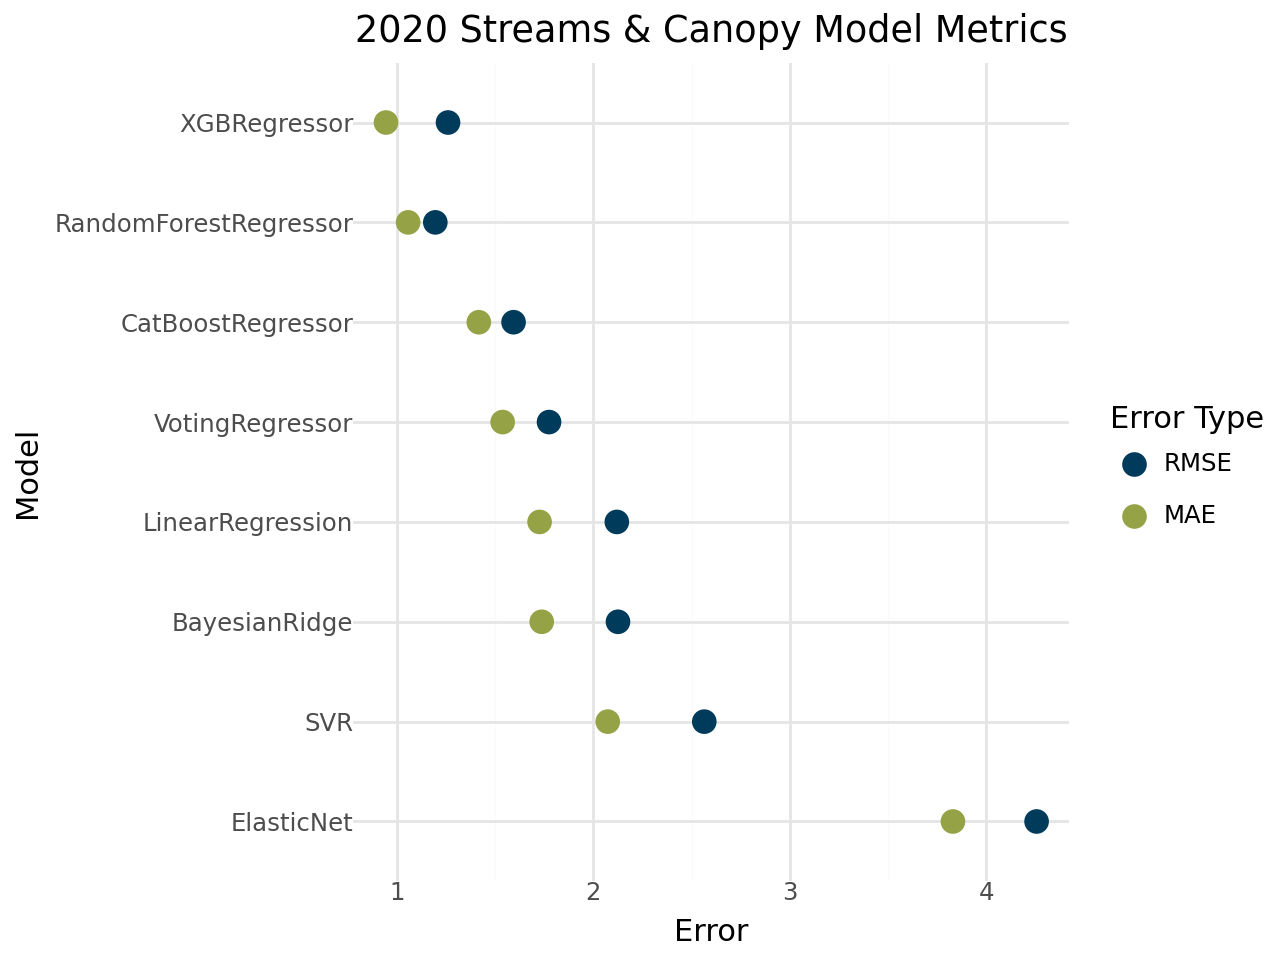

In [ ]:
dict={"Model": name_list,"RMSE":rmse_list,"MAE":mae_list,"R2":r2_list}
graphable=pd.DataFrame(dict)
long=pd.melt(graphable, id_vars=["Model"], value_vars=["RMSE", "MAE"])
order = graphable.sort_values(
    by = "RMSE", ascending = True)["Model"].tolist()
ggplot(long)+aes(x="value", y="reorder(Model, -value)",color="variable")+geom_point(size=4)+labs(x="Error",y="Model",title="2020 Streams & Canopy Model Metrics")+scale_color_manual(
        name="Error Type",
        breaks=["RMSE", "MAE"],
        values=["#003b5c", "#95a346"],
    )+theme_minimal()

[Text(0.5, 0, 'Error'),
 Text(0, 0.5, 'Model Name'),
 Text(0.5, 1.0, '2020 Streams & Canopy Model Metrics')]

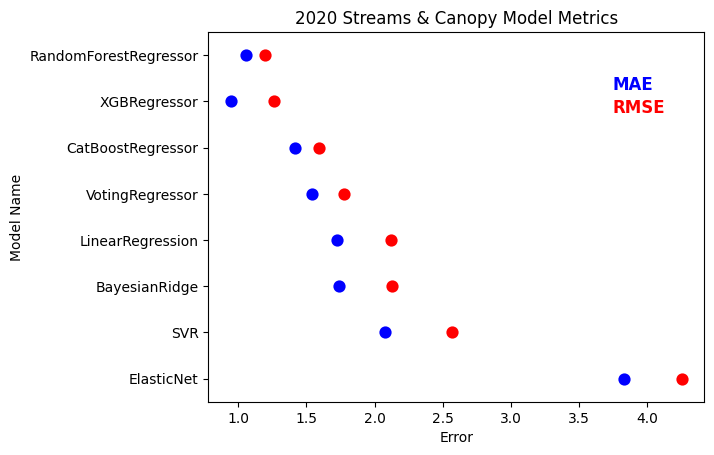

In [ ]:
dict={"Model": name_list,"RMSE":rmse_list,"MAE":mae_list,"R2":r2_list}
graphable=pd.DataFrame(dict)
order = graphable.sort_values(
    by = "RMSE", ascending = True)["Model"].tolist()
sns.pointplot(y = graphable["Model"] , x = graphable["RMSE"],order=order, linestyle='none', color="red")
plt=sns.pointplot(y=graphable["Model"], x=graphable["MAE"],order=order, linestyle='none', color='blue')
plt.text(x=3.75, y=1.25, s="RMSE", fontsize=12, color='red', weight='bold')
plt.text(x=3.75, y=.75, s="MAE", fontsize=12, color='blue', weight='bold')
plt.set(xlabel="Error",ylabel="Model Name",title="2020 Streams & Canopy Model Metrics")

### 2022 Model with Combined Sites for Streams and Merged with Tree Canopy

In [ ]:
scaler = MinMaxScaler()
X = df2022_3[['month_num','season','Impervious_median','Water_median','Herbaceous_median','BareSoilDr_median','PossiblePl_median',
              'Shrub_median','UrbanTreeCanopy_pct_median']] # Deciding to use only mean (not median, max, or min) for tree canopy statistics
y = df2022_3["median_temp_c"] # Target!

feature_preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), ['month_num','Impervious_median','Water_median','Herbaceous_median','BareSoilDr_median',
                                 'PossiblePl_median','Shrub_median','UrbanTreeCanopy_pct_median']),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), ['season'])
    ]
)

lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42)
svr = SVR()
en = ElasticNet()
br = BayesianRidge()
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
cat = CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, verbose=0, random_seed=42)
voting_regressor = VotingRegressor(estimators=[
    ('lr', lr),
    ('rf', rf),
    ('svr', svr),
    ('en', en),
    ('br',br),
    ('xgb',xgb),
    ('cat',cat)
])

models = [lr,rf,svr,en,br,xgb, cat, voting_regressor]
name_list=[]
rmse_list=[]
mae_list=[]
r2_list=[]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for model in models:
    feature_pipeline = Pipeline(steps=[
        ('preprocessor', feature_preprocessor),
        ('model', model)
    ])

    full_pipeline = TransformedTargetRegressor(
        regressor=feature_pipeline,
        transformer=MinMaxScaler()
    )

    cv_results = cross_validate(
        full_pipeline, X, y, cv=kf,
        scoring=['neg_mean_squared_error', 'neg_mean_absolute_error', 'r2']
    )

    rmse_scores = np.sqrt(-cv_results['test_neg_mean_squared_error'])
    mae_scores = -cv_results['test_neg_mean_absolute_error']
    r2_scores = cv_results['test_r2']
    name_list.append(model.__class__.__name__)
    rmse_list.append(np.mean(rmse_scores))
    mae_list.append(np.mean(mae_scores))
    r2_list.append(np.mean(r2_scores))

    print(model.__class__.__name__)
    print("RMSE: ", np.mean(rmse_scores))
    print("MAE: ", np.mean(mae_scores))
    print("R^2: ", np.mean(r2_scores))
    print("")

LinearRegression
RMSE:  2.6743952173087804
MAE:  2.1297385083909584
R^2:  0.6583434415709413

RandomForestRegressor
RMSE:  1.2814007705618704
MAE:  1.0786909615036215
R^2:  0.9140269686611745

SVR
RMSE:  3.197656248353477
MAE:  2.7979693554462877
R^2:  0.44236249457690524

ElasticNet
RMSE:  4.991746964503742
MAE:  4.468522441123188
R^2:  -0.43207550571725994

BayesianRidge
RMSE:  2.660110076644392
MAE:  2.2989772532597086
R^2:  0.6610729509410396

XGBRegressor
RMSE:  0.7191923964807222
MAE:  0.5068911643429083
R^2:  0.9072149261933233

CatBoostRegressor
RMSE:  1.656947764463101
MAE:  1.4162188109270766
R^2:  0.8425837568043522

VotingRegressor
RMSE:  2.02172318545879
MAE:  1.8351343459882883
R^2:  0.7944545281410766



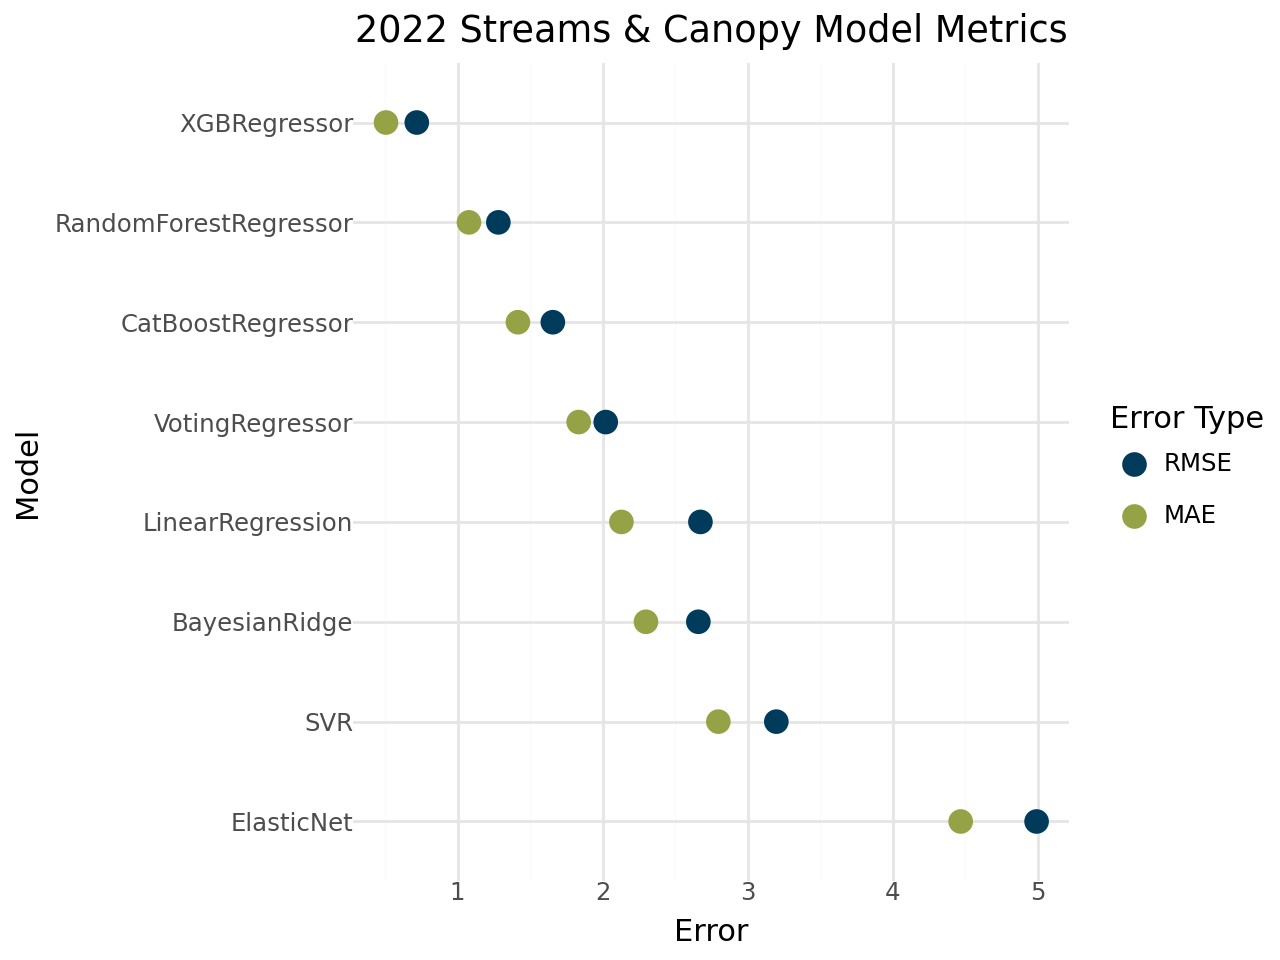

In [ ]:
dict={"Model": name_list,"RMSE":rmse_list,"MAE":mae_list,"R2":r2_list}
graphable=pd.DataFrame(dict)
long=pd.melt(graphable, id_vars=["Model"], value_vars=["RMSE", "MAE"])
order = graphable.sort_values(
    by = "RMSE", ascending = True)["Model"].tolist()
ggplot(long)+aes(x="value", y="reorder(Model, -value)",color="variable")+geom_point(size=4)+labs(x="Error",y="Model",title="2022 Streams & Canopy Model Metrics")+scale_color_manual(
        name="Error Type",
        breaks=["RMSE", "MAE"],
        values=["#003b5c", "#95a346"],
    )+theme_minimal()

[Text(0.5, 0, 'Error'),
 Text(0, 0.5, 'Model Name'),
 Text(0.5, 1.0, '2022 Streams & Canopy Model Metrics')]

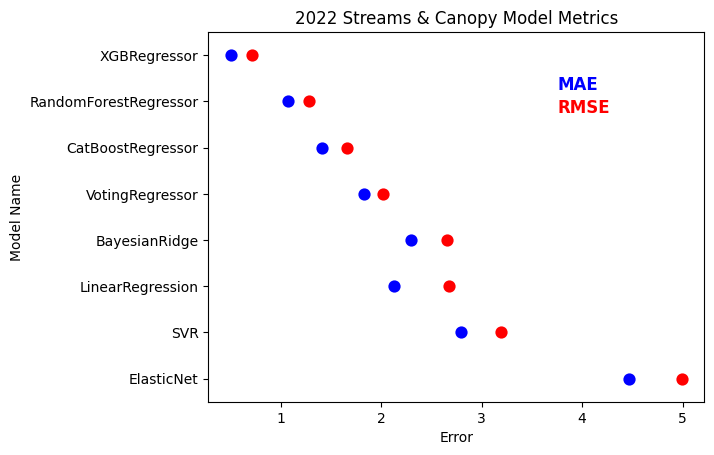

In [ ]:
dict={"Model": name_list,"RMSE":rmse_list,"MAE":mae_list,"R2":r2_list}
graphable=pd.DataFrame(dict)
order = graphable.sort_values(
    by = "RMSE", ascending = True)["Model"].tolist()
sns.pointplot(y = graphable["Model"] , x = graphable["RMSE"],order=order, linestyle='none', color="red")
plt=sns.pointplot(y=graphable["Model"], x=graphable["MAE"],order=order, linestyle='none', color='blue')
plt.text(x=3.75, y=1.25, s="RMSE", fontsize=12, color='red', weight='bold')
plt.text(x=3.75, y=.75, s="MAE", fontsize=12, color='blue', weight='bold')
plt.set(xlabel="Error",ylabel="Model Name",title="2022 Streams & Canopy Model Metrics")

### 2024 Model with Combined Sites for Streams and Merged with Tree Canopy

In [ ]:
scaler = MinMaxScaler()
X = df2024_3[['month_num','season','Impervious_median','Water_median','Herbaceous_median','BareSoilDr_median','PossiblePl_median',
              'Shrub_median','UrbanTreeCanopy_pct_median']] # Deciding to use only mean (not median, max, or min) for tree canopy statistics
y = df2024_3["median_temp_c"] # Target!

feature_preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), ['month_num','Impervious_median','Water_median','Herbaceous_median','BareSoilDr_median',
                                 'PossiblePl_median','Shrub_median','UrbanTreeCanopy_pct_median']),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), ['season'])
    ]
)

lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42)
svr = SVR()
en = ElasticNet()
br = BayesianRidge()
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
cat = CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, verbose=0, random_seed=42)
voting_regressor = VotingRegressor(estimators=[
    ('lr', lr),
    ('rf', rf),
    ('svr', svr),
    ('en', en),
    ('br',br),
    ('xgb',xgb),
    ('cat',cat)
])

models = [lr,rf,svr,en,br,xgb, cat, voting_regressor]
name_list=[]
rmse_list=[]
mae_list=[]
r2_list=[]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for model in models:
    feature_pipeline = Pipeline(steps=[
        ('preprocessor', feature_preprocessor),
        ('model', model)
    ])

    full_pipeline = TransformedTargetRegressor(
        regressor=feature_pipeline,
        transformer=MinMaxScaler()
    )

    cv_results = cross_validate(
        full_pipeline, X, y, cv=kf,
        scoring=['neg_mean_squared_error', 'neg_mean_absolute_error', 'r2']
    )

    rmse_scores = np.sqrt(-cv_results['test_neg_mean_squared_error'])
    mae_scores = -cv_results['test_neg_mean_absolute_error']
    r2_scores = cv_results['test_r2']
    name_list.append(model.__class__.__name__)
    rmse_list.append(np.mean(rmse_scores))
    mae_list.append(np.mean(mae_scores))
    r2_list.append(np.mean(r2_scores))

    print(model.__class__.__name__)
    print("RMSE: ", np.mean(rmse_scores))
    print("MAE: ", np.mean(mae_scores))
    print("R^2: ", np.mean(r2_scores))
    print("")

LinearRegression
RMSE:  2.0456093306144734
MAE:  1.7535466210961386
R^2:  0.7368569678031183

RandomForestRegressor
RMSE:  1.3764982791083082
MAE:  1.2589819898773937
R^2:  0.8623653945979595

SVR
RMSE:  2.715691752849847
MAE:  2.3707953581193992
R^2:  0.5327075606116377

ElasticNet
RMSE:  4.492153273955088
MAE:  3.989187534311256
R^2:  -0.22683659273639445

BayesianRidge
RMSE:  2.01340472467217
MAE:  1.7286229781041988
R^2:  0.7434405704552507

XGBRegressor
RMSE:  1.0840356192387097
MAE:  0.8134901141907427
R^2:  0.8115131268236884

CatBoostRegressor
RMSE:  1.6363552261625176
MAE:  1.4754939519421177
R^2:  0.8030785247846184

VotingRegressor
RMSE:  1.750760553007036
MAE:  1.5714190980505596
R^2:  0.8009463085573663



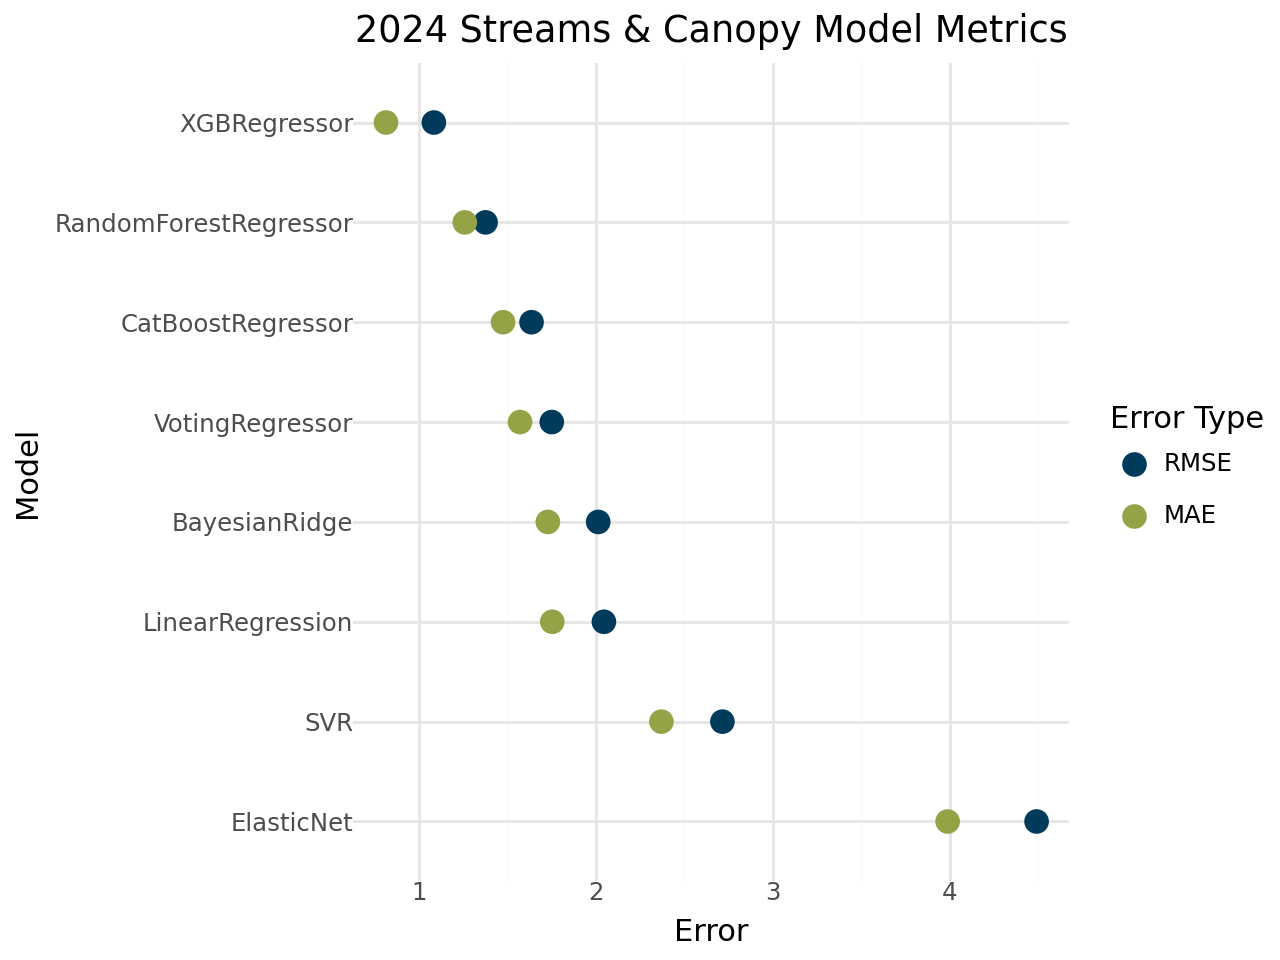

In [ ]:
dict={"Model": name_list,"RMSE":rmse_list,"MAE":mae_list,"R2":r2_list}
graphable=pd.DataFrame(dict)
long=pd.melt(graphable, id_vars=["Model"], value_vars=["RMSE", "MAE"])
order = graphable.sort_values(
    by = "RMSE", ascending = True)["Model"].tolist()
ggplot(long)+aes(x="value", y="reorder(Model, -value)",color="variable")+geom_point(size=4)+labs(x="Error",y="Model",title="2024 Streams & Canopy Model Metrics")+scale_color_manual(
        name="Error Type",
        breaks=["RMSE", "MAE"],
        values=["#003b5c", "#95a346"],
    )+theme_minimal()

[Text(0.5, 0, 'Error'),
 Text(0, 0.5, 'Model Name'),
 Text(0.5, 1.0, '2024 Streams & Canopy Model Metrics')]

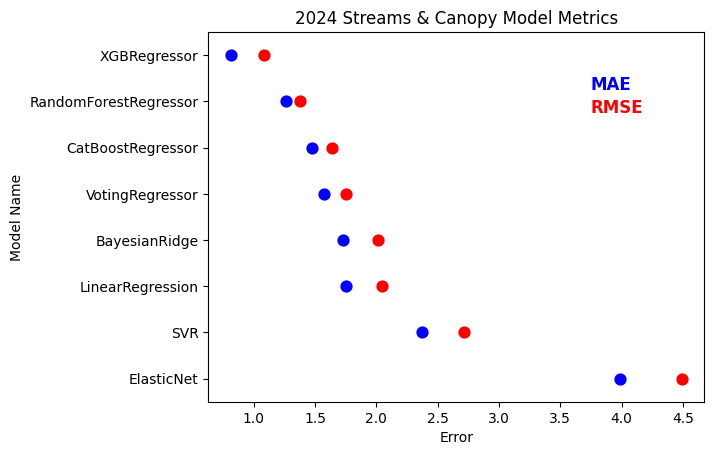

In [ ]:
dict={"Model": name_list,"RMSE":rmse_list,"MAE":mae_list,"R2":r2_list}
graphable=pd.DataFrame(dict)
order = graphable.sort_values(
    by = "RMSE", ascending = True)["Model"].tolist()
sns.pointplot(y = graphable["Model"] , x = graphable["RMSE"],order=order, linestyle='none', color="red")
plt=sns.pointplot(y=graphable["Model"], x=graphable["MAE"],order=order, linestyle='none', color='blue')
plt.text(x=3.75, y=1.25, s="RMSE", fontsize=12, color='red', weight='bold')
plt.text(x=3.75, y=.75, s="MAE", fontsize=12, color='blue', weight='bold')
plt.set(xlabel="Error",ylabel="Model Name",title="2024 Streams & Canopy Model Metrics")

### All Years Model with Combined Sites for Streams and Merged with Tree Canopy

In [ ]:
scaler = MinMaxScaler()
X = dfall_3[['month_num','season','Impervious_median','Water_median','Herbaceous_median','BareSoilDr_median','PossiblePl_median',
              'Shrub_median','UrbanTreeCanopy_pct_median']] # Deciding to use only mean (not median, max, or min) for tree canopy statistics
y = dfall_3["median_temp_c"] # Target!

feature_preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), ['month_num','Impervious_median','Water_median','Herbaceous_median','BareSoilDr_median',
                                 'PossiblePl_median','Shrub_median','UrbanTreeCanopy_pct_median']),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), ['season'])
    ]
)

lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42)
svr = SVR()
en = ElasticNet()
br = BayesianRidge()
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
cat = CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, verbose=0, random_seed=42)
voting_regressor = VotingRegressor(estimators=[
    ('lr', lr),
    ('rf', rf),
    ('svr', svr),
    ('en', en),
    ('br',br),
    ('xgb',xgb),
    ('cat',cat)
])

models = [lr,rf,svr,en,br,xgb, cat, voting_regressor]
name_list=[]
rmse_list=[]
mae_list=[]
r2_list=[]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for model in models:
    feature_pipeline = Pipeline(steps=[
        ('preprocessor', feature_preprocessor),
        ('model', model)
    ])

    full_pipeline = TransformedTargetRegressor(
        regressor=feature_pipeline,
        transformer=MinMaxScaler()
    )

    cv_results = cross_validate(
        full_pipeline, X, y, cv=kf,
        scoring=['neg_mean_squared_error', 'neg_mean_absolute_error', 'r2']
    )

    rmse_scores = np.sqrt(-cv_results['test_neg_mean_squared_error'])
    mae_scores = -cv_results['test_neg_mean_absolute_error']
    r2_scores = cv_results['test_r2']
    name_list.append(model.__class__.__name__)
    rmse_list.append(np.mean(rmse_scores))
    mae_list.append(np.mean(mae_scores))
    r2_list.append(np.mean(r2_scores))

    print(model.__class__.__name__)
    print("RMSE: ", np.mean(rmse_scores))
    print("MAE: ", np.mean(mae_scores))
    print("R^2: ", np.mean(r2_scores))
    print("")

LinearRegression
RMSE:  2.1974170117620453
MAE:  1.7428329846528445
R^2:  0.7655031619505218

RandomForestRegressor
RMSE:  1.0116971935151766
MAE:  0.7815574640057432
R^2:  0.9488948656239191

SVR
RMSE:  2.392117242780367
MAE:  1.9003375659894595
R^2:  0.7208787210203396

ElasticNet
RMSE:  4.557757944104661
MAE:  3.9660528048008152
R^2:  -0.014737183407715326

BayesianRidge
RMSE:  2.181200786259633
MAE:  1.7272195729169955
R^2:  0.7690487187919419

XGBRegressor
RMSE:  1.0749067484125152
MAE:  0.8356859636667366
R^2:  0.9427224999109021

CatBoostRegressor
RMSE:  0.951191119564981
MAE:  0.7475806288077883
R^2:  0.9555724123295054

VotingRegressor
RMSE:  1.6221890556519647
MAE:  1.355996774063964
R^2:  0.8715088707223838



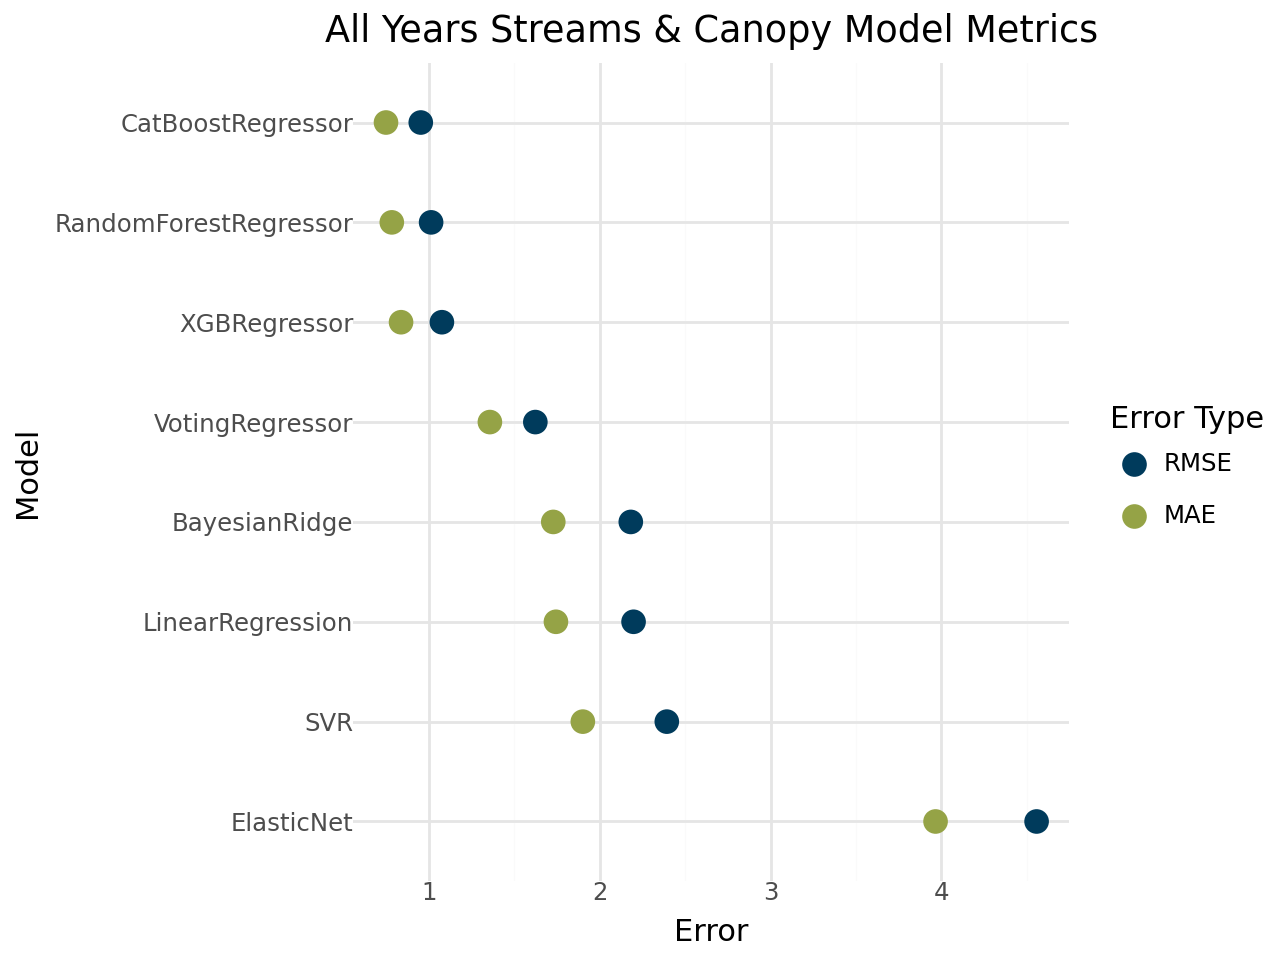

In [ ]:
dict={"Model": name_list,"RMSE":rmse_list,"MAE":mae_list,"R2":r2_list}
graphable=pd.DataFrame(dict)
long=pd.melt(graphable, id_vars=["Model"], value_vars=["RMSE", "MAE"])
order = graphable.sort_values(
    by = "RMSE", ascending = True)["Model"].tolist()
ggplot(long)+aes(x="value", y="reorder(Model, -value)",color="variable")+geom_point(size=4)+labs(x="Error",y="Model",title="All Years Streams & Canopy Model Metrics")+scale_color_manual(
        name="Error Type",
        breaks=["RMSE", "MAE"],
        values=["#003b5c", "#95a346"],
    )+theme_minimal()

[Text(0.5, 0, 'Error'),
 Text(0, 0.5, 'Model Name'),
 Text(0.5, 1.0, 'All Years Streams & Canopy Model Metrics')]

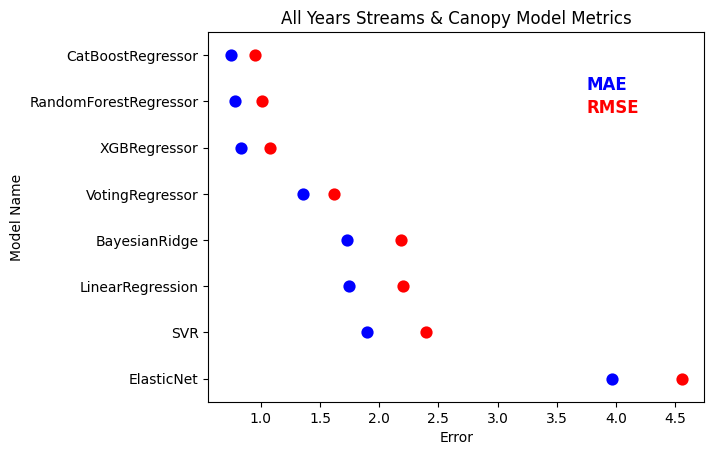

In [ ]:
dict={"Model": name_list,"RMSE":rmse_list,"MAE":mae_list,"R2":r2_list}
graphable=pd.DataFrame(dict)
order = graphable.sort_values(
    by = "RMSE", ascending = True)["Model"].tolist()
sns.pointplot(y = graphable["Model"] , x = graphable["RMSE"],order=order, linestyle='none', color="red")
plt=sns.pointplot(y=graphable["Model"], x=graphable["MAE"],order=order, linestyle='none', color='blue')
plt.text(x=3.75, y=1.25, s="RMSE", fontsize=12, color='red', weight='bold')
plt.text(x=3.75, y=.75, s="MAE", fontsize=12, color='blue', weight='bold')
plt.set(xlabel="Error",ylabel="Model Name",title="All Years Streams & Canopy Model Metrics")

## *RQ #4: Will combining all three historic datasets–streams, weather, and canopy–produce a highly accurate prediction of stream temperature in 2020, 2022, and 2024?*


In [ ]:
# DESIGNING MODEL DATASET

# Merging all three years of stream and tree canopy data (ex: df2024_3) with weather data (ex: weather2024)
df2020_4 = pd.merge(df2020_3, weather2020, on=["start_date","year_num","month_num", "season", "end_date"])
df2022_4 = pd.merge(df2022_3, weather2022, on=["start_date","year_num","month_num", "season", "end_date"])
df2024_4 = pd.merge(df2024_3, weather2024, on=["start_date","year_num","month_num", "season", "end_date"])

dfall_4 = pd.merge(dfall_3, weather, on=["start_date","year_num","month_num", "season", "end_date"])

dfall_4.head()

,year_num,month_num,season,start_date,end_date,median_temp_c,Impervious_median,Water_median,Herbaceous_median,BareSoilDr_median,PossiblePl_median,Shrub_median,UrbanTreeCanopy_pct_median,median_max_temp_f,median_precip
0,2020,1,Winter,2020-01-01,2020-01-31,8.406771,61.40615,0.0,9.10206,0.0,9.163391,0.088565,32.023561,50.0,0.19
1,2020,2,Winter,2020-02-01,2020-02-29,7.483750,61.40615,0.0,9.10206,0.0,9.163391,0.088565,32.023561,51.0,0.00
2,2020,3,Spring,2020-03-01,2020-03-31,9.178750,61.40615,0.0,9.10206,0.0,9.163391,0.088565,32.023561,53.0,0.00
3,2020,4,Spring,2020-04-01,2020-04-30,12.796823,61.40615,0.0,9.10206,0.0,9.163391,0.088565,32.023561,64.0,0.00
4,2020,5,Spring,2020-05-01,2020-05-31,14.913958,61.40615,0.0,9.10206,0.0,9.163391,0.088565,32.023561,67.0,0.00


### 2020 Model with Combined Sites for Streams Merged with Tree Canopy and Weather

In [ ]:
scaler = MinMaxScaler()
X = df2020_4[['month_num','season','Impervious_median','Water_median','Herbaceous_median','BareSoilDr_median','PossiblePl_median',
              'Shrub_median','UrbanTreeCanopy_pct_median', 'median_max_temp_f', 'median_precip']] # Deciding to use only mean (not median, max, or min) for tree canopy statistics
y = df2020_4["median_temp_c"] # Target!

feature_preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), ['month_num','Impervious_median','Water_median','Herbaceous_median','BareSoilDr_median',
                                 'PossiblePl_median','Shrub_median','UrbanTreeCanopy_pct_median', 'median_max_temp_f', 'median_precip']),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), ['season'])
    ]
)

lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42)
svr = SVR()
en = ElasticNet()
br = BayesianRidge()
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
cat = CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, verbose=0, random_seed=42)
voting_regressor = VotingRegressor(estimators=[
    ('lr', lr),
    ('rf', rf),
    ('svr', svr),
    ('en', en),
    ('br',br),
    ('xgb',xgb),
    ('cat',cat)
])

models = [lr,rf,svr,en,br,xgb, cat, voting_regressor]
name_list=[]
rmse_list=[]
mae_list=[]
r2_list=[]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for model in models:
    feature_pipeline = Pipeline(steps=[
        ('preprocessor', feature_preprocessor),
        ('model', model)
    ])

    full_pipeline = TransformedTargetRegressor(
        regressor=feature_pipeline,
        transformer=MinMaxScaler()
    )

    cv_results = cross_validate(
        full_pipeline, X, y, cv=kf,
        scoring=['neg_mean_squared_error', 'neg_mean_absolute_error', 'r2']
    )

    rmse_scores = np.sqrt(-cv_results['test_neg_mean_squared_error'])
    mae_scores = -cv_results['test_neg_mean_absolute_error']
    r2_scores = cv_results['test_r2']
    name_list.append(model.__class__.__name__)
    rmse_list.append(np.mean(rmse_scores))
    mae_list.append(np.mean(mae_scores))
    r2_list.append(np.mean(r2_scores))

    print(model.__class__.__name__)
    print("RMSE: ", np.mean(rmse_scores))
    print("MAE: ", np.mean(mae_scores))
    print("R^2: ", np.mean(r2_scores))
    print("")

LinearRegression
RMSE:  2.337610972113435
MAE:  1.9262017016883894
R^2:  0.2523556638178556

RandomForestRegressor
RMSE:  0.8710858847427942
MAE:  0.7331005840252763
R^2:  0.9435541523027698

SVR
RMSE:  2.2262607441535494
MAE:  1.939096752272074
R^2:  0.6417730423530703

ElasticNet
RMSE:  4.204249933131849
MAE:  3.8544350965882392
R^2:  -0.1684057722349101

BayesianRidge
RMSE:  1.7798010002310627
MAE:  1.4265299668183098
R^2:  0.6754631324742704

XGBRegressor
RMSE:  0.9076014104523142
MAE:  0.6805028049347637
R^2:  0.9400957058372352

CatBoostRegressor
RMSE:  1.2889890804671624
MAE:  1.2057679124486955
R^2:  0.873802032433322

VotingRegressor
RMSE:  1.175484545708266
MAE:  1.0691214572027732
R^2:  0.9052700588901876



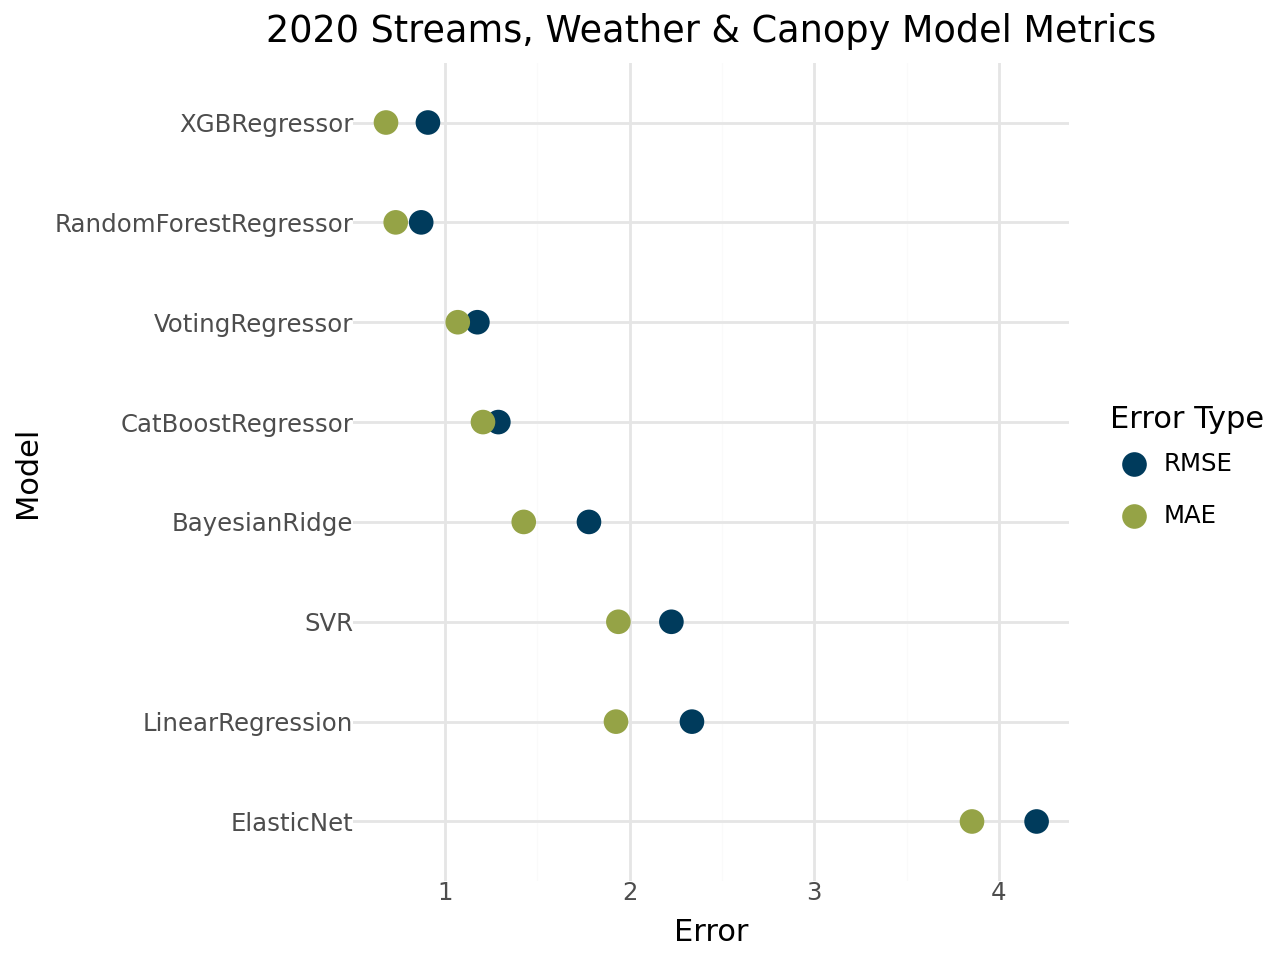

In [ ]:
dict={"Model": name_list,"RMSE":rmse_list,"MAE":mae_list,"R2":r2_list}
graphable=pd.DataFrame(dict)
long=pd.melt(graphable, id_vars=["Model"], value_vars=["RMSE", "MAE"])
order = graphable.sort_values(
    by = "RMSE", ascending = True)["Model"].tolist()
ggplot(long)+aes(x="value", y="reorder(Model, -value)",color="variable")+geom_point(size=4)+labs(x="Error",y="Model",title="2020 Streams, Weather & Canopy Model Metrics")+scale_color_manual(
        name="Error Type",
        breaks=["RMSE", "MAE"],
        values=["#003b5c", "#95a346"],
    )+theme_minimal()

[Text(0.5, 0, 'Error'),
 Text(0, 0.5, 'Model Name'),
 Text(0.5, 1.0, '2020 Streams, Weather, & Canopy Model Metrics')]

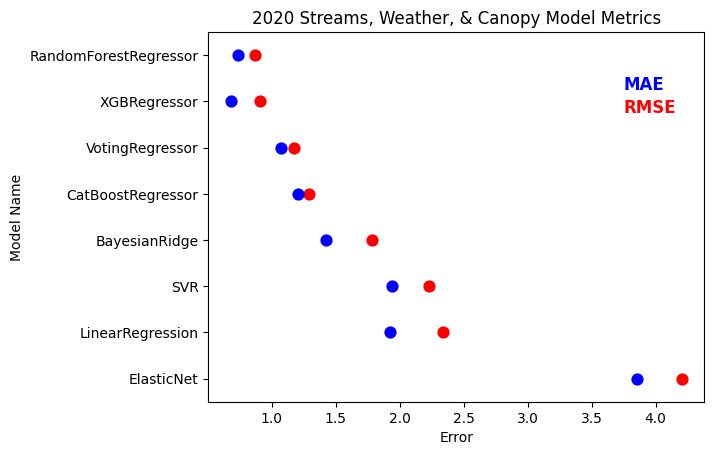

In [ ]:
dict={"Model": name_list,"RMSE":rmse_list,"MAE":mae_list,"R2":r2_list}
graphable=pd.DataFrame(dict)
order = graphable.sort_values(
    by = "RMSE", ascending = True)["Model"].tolist()
sns.pointplot(y = graphable["Model"] , x = graphable["RMSE"],order=order, linestyle='none', color="red")
plt=sns.pointplot(y=graphable["Model"], x=graphable["MAE"],order=order, linestyle='none', color='blue')
plt.text(x=3.75, y=1.25, s="RMSE", fontsize=12, color='red', weight='bold')
plt.text(x=3.75, y=.75, s="MAE", fontsize=12, color='blue', weight='bold')
plt.set(xlabel="Error",ylabel="Model Name",title="2020 Streams, Weather, & Canopy Model Metrics")

### 2022 Model with Combined Sites for Streams Merged with Tree Canopy and Weather

In [ ]:
scaler = MinMaxScaler()
X = df2022_4[['month_num','season','Impervious_median','Water_median','Herbaceous_median','BareSoilDr_median','PossiblePl_median',
              'Shrub_median','UrbanTreeCanopy_pct_median', 'median_max_temp_f', 'median_precip']] # Deciding to use only mean (not median, max, or min) for tree canopy statistics
y = df2022_4["median_temp_c"] # Target!

feature_preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), ['month_num','Impervious_median','Water_median','Herbaceous_median','BareSoilDr_median',
                                 'PossiblePl_median','Shrub_median','UrbanTreeCanopy_pct_median', 'median_max_temp_f', 'median_precip']),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), ['season'])
    ]
)

lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42)
svr = SVR()
en = ElasticNet()
br = BayesianRidge()
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
cat = CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, verbose=0, random_seed=42)
voting_regressor = VotingRegressor(estimators=[
    ('lr', lr),
    ('rf', rf),
    ('svr', svr),
    ('en', en),
    ('br',br),
    ('xgb',xgb),
    ('cat',cat)
])

models = [lr,rf,svr,en,br,xgb, cat, voting_regressor]
name_list.append(model.__class__.__name__)
rmse_list.append(np.mean(rmse_scores))
mae_list.append(np.mean(mae_scores))
r2_list.append(np.mean(r2_scores))

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for model in models:
    feature_pipeline = Pipeline(steps=[
        ('preprocessor', feature_preprocessor),
        ('model', model)
    ])

    full_pipeline = TransformedTargetRegressor(
        regressor=feature_pipeline,
        transformer=MinMaxScaler()
    )

    cv_results = cross_validate(
        full_pipeline, X, y, cv=kf,
        scoring=['neg_mean_squared_error', 'neg_mean_absolute_error', 'r2']
    )

    rmse_scores = np.sqrt(-cv_results['test_neg_mean_squared_error'])
    mae_scores = -cv_results['test_neg_mean_absolute_error']
    r2_scores = cv_results['test_r2']
    name_list.append(model.__class__.__name__)
    rmse_list.append(np.mean(rmse_scores))
    mae_list.append(np.mean(mae_scores))
    r2_list.append(np.mean(r2_scores))

    print(model.__class__.__name__)
    print("RMSE: ", np.mean(rmse_scores))
    print("MAE: ", np.mean(mae_scores))
    print("R^2: ", np.mean(r2_scores))
    print("")

LinearRegression
RMSE:  1.0629314940758614
MAE:  0.7902244180992624
R^2:  0.3408322214373583

RandomForestRegressor
RMSE:  0.8249355365389823
MAE:  0.6696997214673901
R^2:  0.8959288390139781

SVR
RMSE:  1.986628419472099
MAE:  1.7611027687615846
R^2:  0.7814407029118128

ElasticNet
RMSE:  4.991746964503742
MAE:  4.468522441123188
R^2:  -0.43207550571725994

BayesianRidge
RMSE:  0.9475316016133355
MAE:  0.7156013302968111
R^2:  0.5218530585612358

XGBRegressor
RMSE:  0.7273203342091861
MAE:  0.5204497131264733
R^2:  0.6761248087197917

CatBoostRegressor
RMSE:  0.9693777688371588
MAE:  0.8210803994048671
R^2:  0.9377203753312525

VotingRegressor
RMSE:  1.1343901752836392
MAE:  1.0501126117758377
R^2:  0.9170636766722033



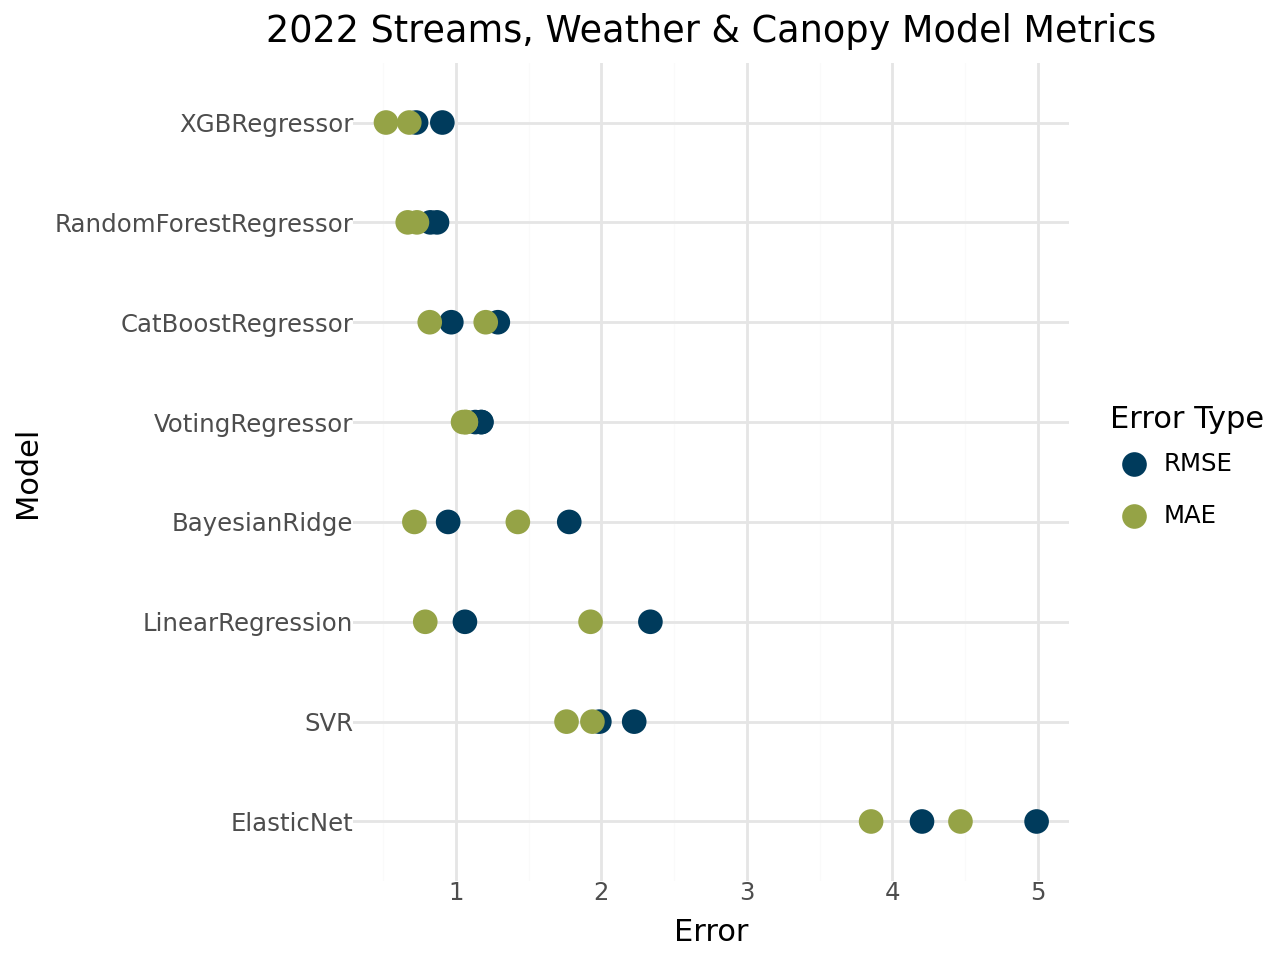

In [ ]:
dict={"Model": name_list,"RMSE":rmse_list,"MAE":mae_list,"R2":r2_list}
graphable=pd.DataFrame(dict)
long=pd.melt(graphable, id_vars=["Model"], value_vars=["RMSE", "MAE"])
order = graphable.sort_values(
    by = "RMSE", ascending = True)["Model"].tolist()
ggplot(long)+aes(x="value", y="reorder(Model, -value)",color="variable")+geom_point(size=4)+labs(x="Error",y="Model",title="2022 Streams, Weather & Canopy Model Metrics")+scale_color_manual(
        name="Error Type",
        breaks=["RMSE", "MAE"],
        values=["#003b5c", "#95a346"],
    )+theme_minimal()

[Text(0.5, 0, 'Error'),
 Text(0, 0.5, 'Model Name'),
 Text(0.5, 1.0, '2022 Streams, Weather, & Canopy Model Metrics')]

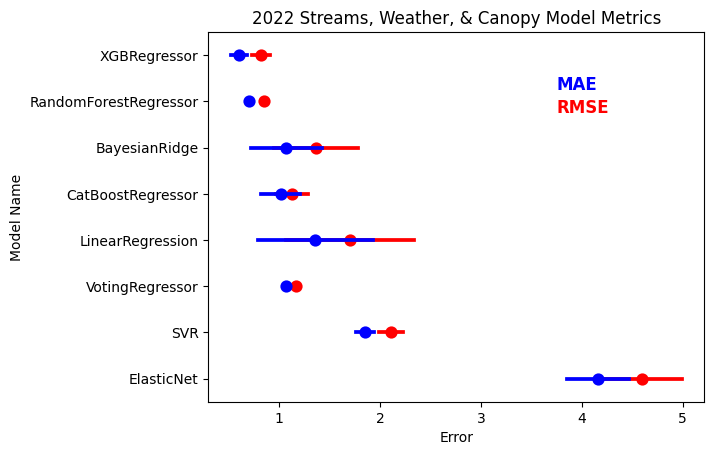

In [ ]:
dict={"Model": name_list,"RMSE":rmse_list,"MAE":mae_list,"R2":r2_list}
graphable=pd.DataFrame(dict)
order = graphable.sort_values(
    by = "RMSE", ascending = True)["Model"].tolist()
sns.pointplot(y = graphable["Model"] , x = graphable["RMSE"],order=order, linestyle='none', color="red")
plt=sns.pointplot(y=graphable["Model"], x=graphable["MAE"],order=order, linestyle='none', color='blue')
plt.text(x=3.75, y=1.25, s="RMSE", fontsize=12, color='red', weight='bold')
plt.text(x=3.75, y=.75, s="MAE", fontsize=12, color='blue', weight='bold')
plt.set(xlabel="Error",ylabel="Model Name",title="2022 Streams, Weather, & Canopy Model Metrics")

### 2024 Model with Combined Sites for Streams Merged with Tree Canopy and Weather

In [ ]:
scaler = MinMaxScaler()
X = df2024_4[['month_num','season','Impervious_median','Water_median','Herbaceous_median','BareSoilDr_median','PossiblePl_median',
              'Shrub_median','UrbanTreeCanopy_pct_median', 'median_max_temp_f', 'median_precip']] # Deciding to use only mean (not median, max, or min) for tree canopy statistics
y = df2024_4["median_temp_c"] # Target!

feature_preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), ['month_num','Impervious_median','Water_median','Herbaceous_median','BareSoilDr_median',
                                 'PossiblePl_median','Shrub_median','UrbanTreeCanopy_pct_median', 'median_max_temp_f', 'median_precip']),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), ['season'])
    ]
)

lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42)
svr = SVR()
en = ElasticNet()
br = BayesianRidge()
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
cat = CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, verbose=0, random_seed=42)
voting_regressor = VotingRegressor(estimators=[
    ('lr', lr),
    ('rf', rf),
    ('svr', svr),
    ('en', en),
    ('br',br),
    ('xgb',xgb),
    ('cat',cat)
])

models = [lr,rf,svr,en,br,xgb, cat, voting_regressor]
name_list=[]
rmse_list=[]
mae_list=[]
r2_list=[]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for model in models:
    feature_pipeline = Pipeline(steps=[
        ('preprocessor', feature_preprocessor),
        ('model', model)
    ])

    full_pipeline = TransformedTargetRegressor(
        regressor=feature_pipeline,
        transformer=MinMaxScaler()
    )

    cv_results = cross_validate(
        full_pipeline, X, y, cv=kf,
        scoring=['neg_mean_squared_error', 'neg_mean_absolute_error', 'r2']
    )

    rmse_scores = np.sqrt(-cv_results['test_neg_mean_squared_error'])
    mae_scores = -cv_results['test_neg_mean_absolute_error']
    r2_scores = cv_results['test_r2']
    name_list.append(model.__class__.__name__)
    rmse_list.append(np.mean(rmse_scores))
    mae_list.append(np.mean(mae_scores))
    r2_list.append(np.mean(r2_scores))

    print(model.__class__.__name__)
    print("RMSE: ", np.mean(rmse_scores))
    print("MAE: ", np.mean(mae_scores))
    print("R^2: ", np.mean(r2_scores))
    print("")

LinearRegression
RMSE:  0.8281038610671597
MAE:  0.7352782612016358
R^2:  0.9492416201303862

RandomForestRegressor
RMSE:  0.9210951250998104
MAE:  0.7537144171401507
R^2:  0.9516719370234927

SVR
RMSE:  2.34808882432351
MAE:  2.134899500782102
R^2:  0.6834313472910667

ElasticNet
RMSE:  4.738273597381685
MAE:  4.2069432957086335
R^2:  -0.23758660383983732

BayesianRidge
RMSE:  0.7657647760687837
MAE:  0.686503652137353
R^2:  0.9582093886560124

XGBRegressor
RMSE:  0.7532131243616389
MAE:  0.545386694973546
R^2:  0.9602426568227106

CatBoostRegressor
RMSE:  1.724906335252075
MAE:  1.484628066994291
R^2:  0.8316892381255429

VotingRegressor
RMSE:  1.4221805025481942
MAE:  1.2646604784640636
R^2:  0.8869302748732156



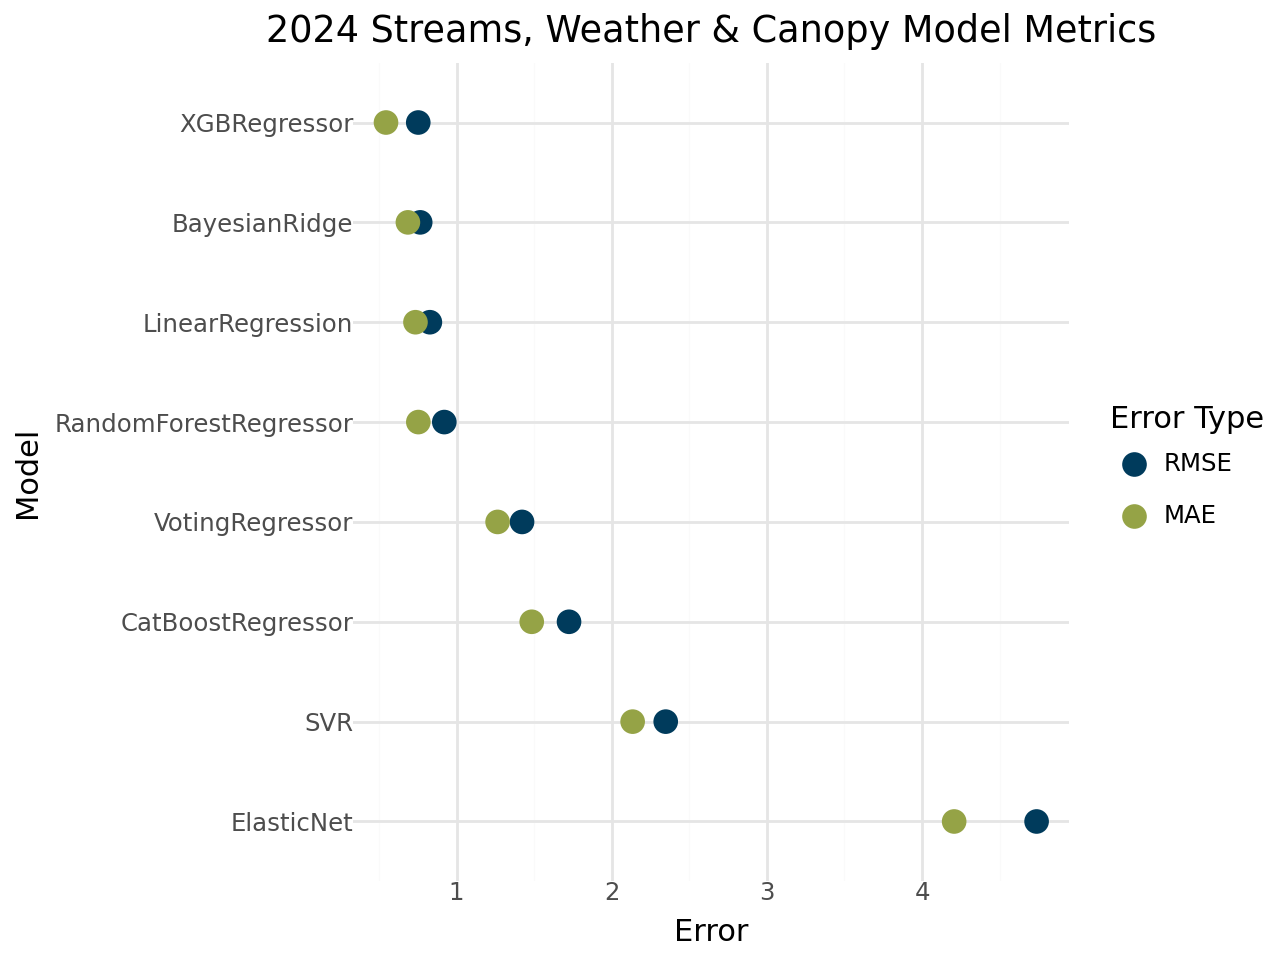

In [ ]:
dict={"Model": name_list,"RMSE":rmse_list,"MAE":mae_list,"R2":r2_list}
graphable=pd.DataFrame(dict)
long=pd.melt(graphable, id_vars=["Model"], value_vars=["RMSE", "MAE"])
order = graphable.sort_values(
    by = "RMSE", ascending = True)["Model"].tolist()
ggplot(long)+aes(x="value", y="reorder(Model, -value)",color="variable")+geom_point(size=4)+labs(x="Error",y="Model",title="2024 Streams, Weather & Canopy Model Metrics")+scale_color_manual(
        name="Error Type",
        breaks=["RMSE", "MAE"],
        values=["#003b5c", "#95a346"],
    )+theme_minimal()

[Text(0.5, 0, 'Error'),
 Text(0, 0.5, 'Model Name'),
 Text(0.5, 1.0, '2024 Streams, Weather, & Canopy Model Metrics')]

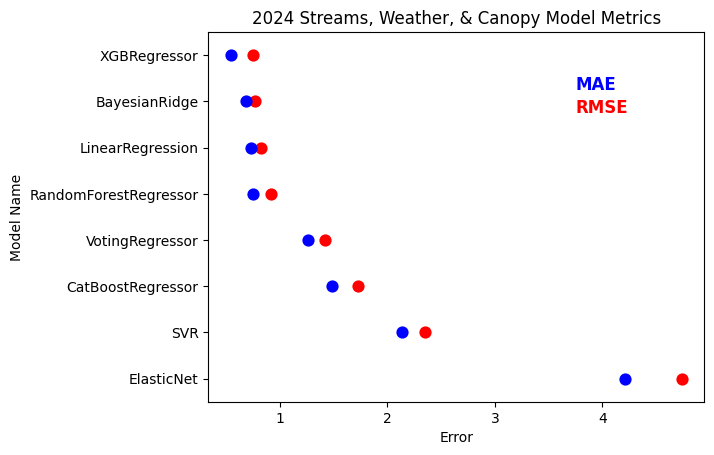

In [ ]:
dict={"Model": name_list,"RMSE":rmse_list,"MAE":mae_list,"R2":r2_list}
graphable=pd.DataFrame(dict)
order = graphable.sort_values(
    by = "RMSE", ascending = True)["Model"].tolist()
sns.pointplot(y = graphable["Model"] , x = graphable["RMSE"],order=order, linestyle='none', color="red")
plt=sns.pointplot(y=graphable["Model"], x=graphable["MAE"],order=order, linestyle='none', color='blue')
plt.text(x=3.75, y=1.25, s="RMSE", fontsize=12, color='red', weight='bold')
plt.text(x=3.75, y=.75, s="MAE", fontsize=12, color='blue', weight='bold')
plt.set(xlabel="Error",ylabel="Model Name",title="2024 Streams, Weather, & Canopy Model Metrics")

### All Years Model with Combined Sites for Streams Merged with Tree Canopy and Weather

In [ ]:
scaler = MinMaxScaler()
X = dfall_4[['month_num','season','Impervious_median','Water_median','Herbaceous_median','BareSoilDr_median','PossiblePl_median',
              'Shrub_median','UrbanTreeCanopy_pct_median', 'median_max_temp_f', 'median_precip']] # Deciding to use only mean (not median, max, or min) for tree canopy statistics
y = dfall_4["median_temp_c"] # Target!

feature_preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), ['month_num','Impervious_median','Water_median','Herbaceous_median','BareSoilDr_median',
                                 'PossiblePl_median','Shrub_median','UrbanTreeCanopy_pct_median', 'median_max_temp_f', 'median_precip']),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), ['season'])
    ]
)

lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42)
svr = SVR()
en = ElasticNet()
br = BayesianRidge()
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
cat = CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, verbose=0, random_seed=42)
voting_regressor = VotingRegressor(estimators=[
    ('lr', lr),
    ('rf', rf),
    ('svr', svr),
    ('en', en),
    ('br',br),
    ('xgb',xgb),
    ('cat',cat)
])

models = [lr,rf,svr,en,br,xgb, cat, voting_regressor]
name_list=[]
rmse_list=[]
mae_list=[]
r2_list=[]

name_list.append(model.__class__.__name__)
rmse_list.append(np.mean(rmse_scores))
mae_list.append(np.mean(mae_scores))
r2_list.append(np.mean(r2_scores))

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for model in models:
    feature_pipeline = Pipeline(steps=[
        ('preprocessor', feature_preprocessor),
        ('model', model)
    ])

    full_pipeline = TransformedTargetRegressor(
        regressor=feature_pipeline,
        transformer=MinMaxScaler()
    )

    cv_results = cross_validate(
        full_pipeline, X, y, cv=kf,
        scoring=['neg_mean_squared_error', 'neg_mean_absolute_error', 'r2']
    )

    rmse_scores = np.sqrt(-cv_results['test_neg_mean_squared_error'])
    mae_scores = -cv_results['test_neg_mean_absolute_error']
    r2_scores = cv_results['test_r2']
    name_list.append(model.__class__.__name__)
    rmse_list.append(np.mean(rmse_scores))
    mae_list.append(np.mean(mae_scores))
    r2_list.append(np.mean(r2_scores))

    print(model.__class__.__name__)
    print("RMSE: ", np.mean(rmse_scores))
    print("MAE: ", np.mean(mae_scores))
    print("R^2: ", np.mean(r2_scores))
    print("")

LinearRegression
RMSE:  0.6719295583122669
MAE:  0.5592846250947456
R^2:  0.9703471229647193

RandomForestRegressor
RMSE:  0.5885281868864798
MAE:  0.4643228032127441
R^2:  0.9818725323466886

SVR
RMSE:  1.3987058537052097
MAE:  1.1718825318818717
R^2:  0.8829434720876337

ElasticNet
RMSE:  4.703435770346856
MAE:  4.083272665006871
R^2:  -0.19101598084391974

BayesianRidge
RMSE:  0.6712524557822068
MAE:  0.5593538114528542
R^2:  0.9703660419485379

XGBRegressor
RMSE:  0.4895654523314379
MAE:  0.3768546598641454
R^2:  0.9873822234218672

CatBoostRegressor
RMSE:  0.7354511140077171
MAE:  0.6111482533047047
R^2:  0.9705830226175826

VotingRegressor
RMSE:  1.035910743179223
MAE:  0.895374502223717
R^2:  0.936452041077955



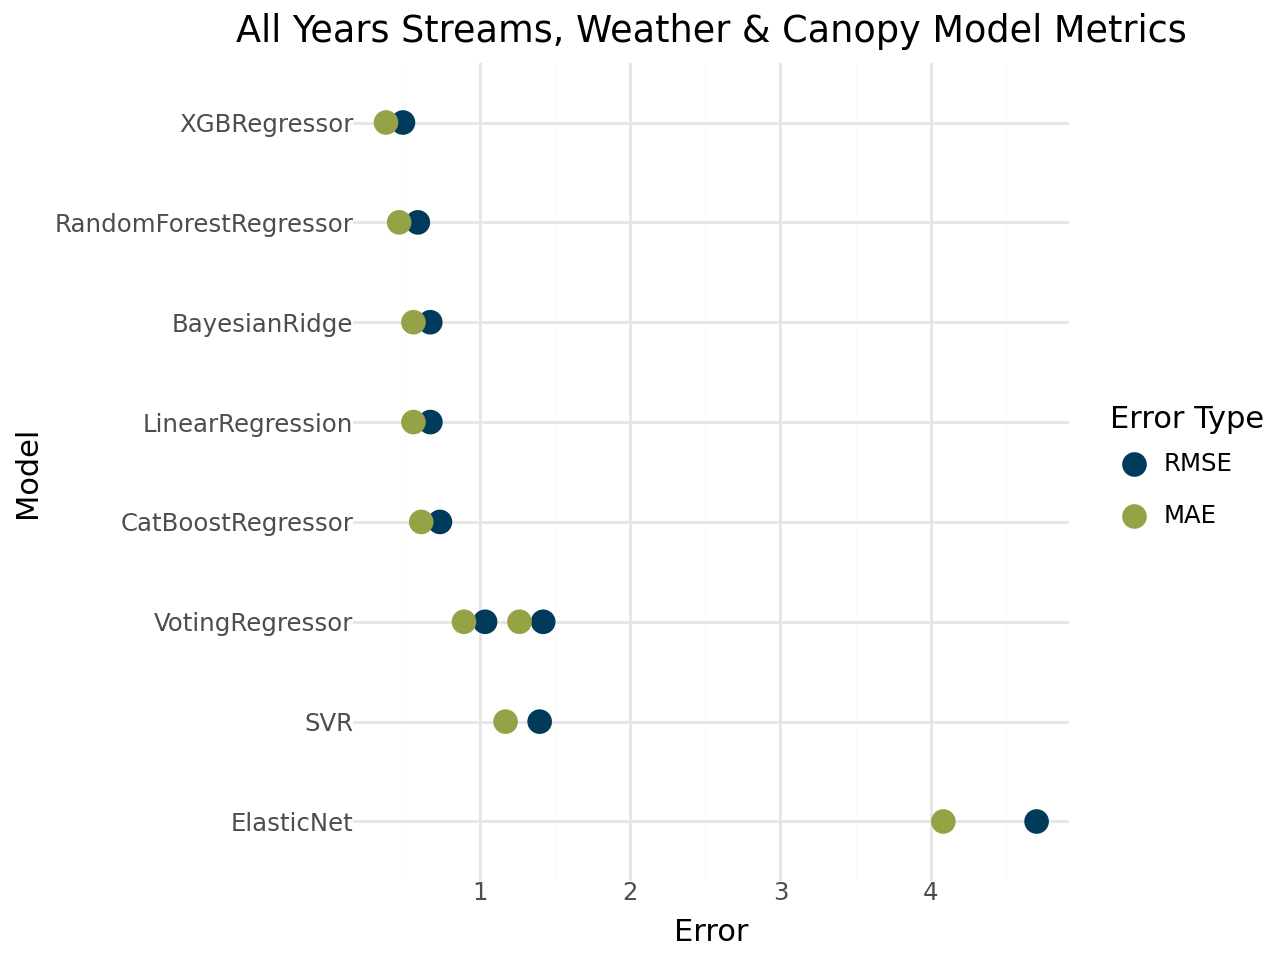

In [ ]:
dict={"Model": name_list,"RMSE":rmse_list,"MAE":mae_list,"R2":r2_list}
graphable=pd.DataFrame(dict)
long=pd.melt(graphable, id_vars=["Model"], value_vars=["RMSE", "MAE"])
order = graphable.sort_values(
    by = "RMSE", ascending = True)["Model"].tolist()
ggplot(long)+aes(x="value", y="reorder(Model, -value)",color="variable")+geom_point(size=4)+labs(x="Error",y="Model",title="All Years Streams, Weather & Canopy Model Metrics")+scale_color_manual(
        name="Error Type",
        breaks=["RMSE", "MAE"],
        values=["#003b5c", "#95a346"],
    )+theme_minimal()

[Text(0.5, 0, 'Error'),
 Text(0, 0.5, 'Model Name'),
 Text(0.5, 1.0, 'All Years Streams, Weather, & Canopy Model Metrics')]

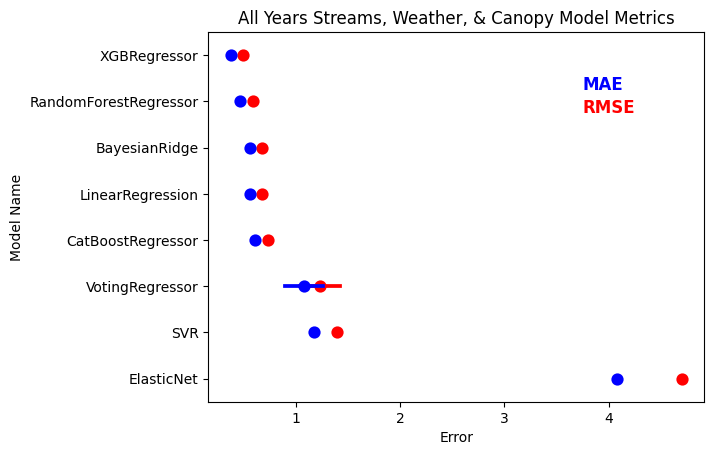

In [ ]:
dict={"Model": name_list,"RMSE":rmse_list,"MAE":mae_list,"R2":r2_list}
graphable=pd.DataFrame(dict)
order = graphable.sort_values(
    by = "RMSE", ascending = True)["Model"].tolist()
sns.pointplot(y = graphable["Model"] , x = graphable["RMSE"],order=order, linestyle='none', color="red")
plt=sns.pointplot(y=graphable["Model"], x=graphable["MAE"],order=order, linestyle='none', color='blue')
plt.text(x=3.75, y=1.25, s="RMSE", fontsize=12, color='red', weight='bold')
plt.text(x=3.75, y=.75, s="MAE", fontsize=12, color='blue', weight='bold')
plt.set(xlabel="Error",ylabel="Model Name",title="All Years Streams, Weather, & Canopy Model Metrics")

## Looking at Correlation Between Variables

### Correlation Between Stream Temperature and Weather

In [ ]:
# Compute correlation between stream temperature (median_temp_c) and weather temperature (median_max_temp_f)
correlation = dfall_4['median_temp_c'].corr(dfall_4['median_max_temp_f'])
print(f"Correlation Stream Temp and Weather Temp: {correlation}")

Correlation Stream Temp and Weather Temp: 0.9814423226386221


### Correlation Between Stream Temperature and Tree Canopy

In [ ]:
# Compute correlation between stream temperature (median_temp_c) and tree canopy coverage (median_max_temp_f)
correlation = dfall_4['median_temp_c'].corr(dfall_4['UrbanTreeCanopy_pct_median'])
print(f"Correlation Stream Temp and Tree Canopy Coverage: {correlation}")

Correlation Stream Temp and Tree Canopy Coverage: -0.0800929496981016


### Correlation Heatmap


Notes:

**Every land cover column is perfectly collinear with each other:** This is because the land cover variables repeat values for each month in the year. This is a lack of data issue because we only have data for two sites. This means that every land cover variable is basically just an indicator of site.

**Urban tree canopy coverage weekly correlates with stream temperature:** There is a very weak correlation of -0.08.

**Weather temperature strongly correlates with stream temperature:** As expected, there is a strong correlation between weather temperature and stream temperature with a value of 0.98.

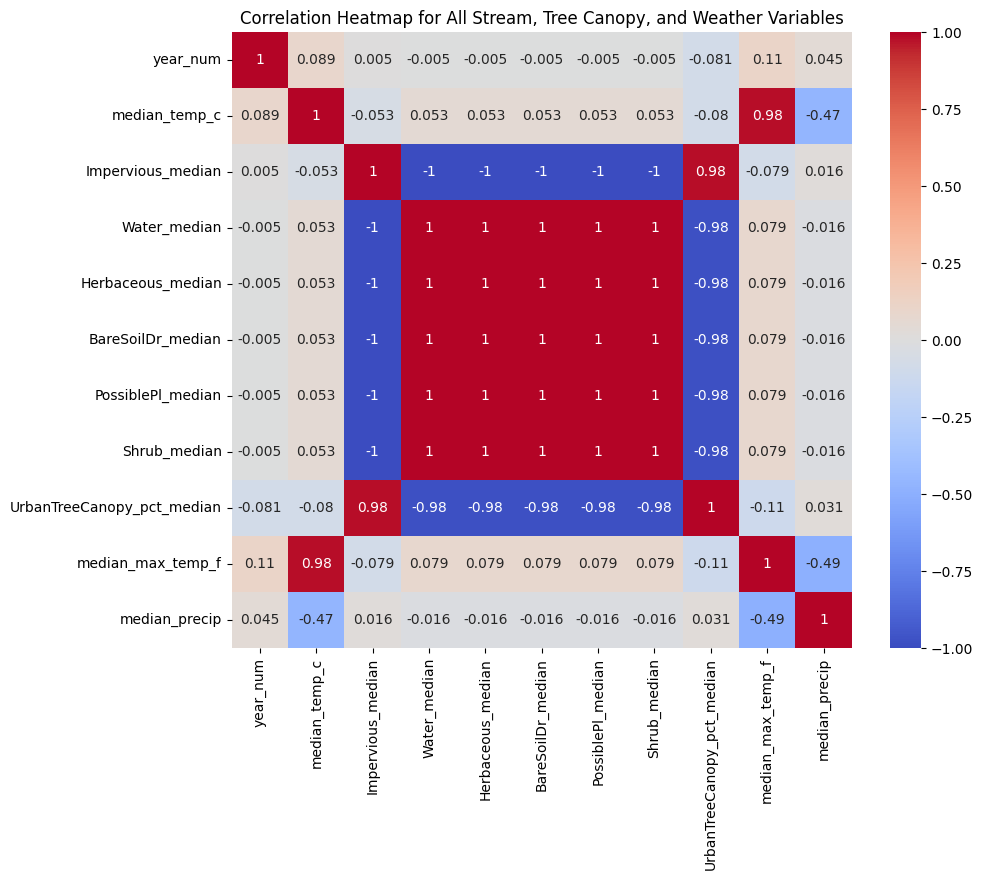

In [ ]:
# Need to reimport this because a figure object was defined earlier
import matplotlib.pyplot as plt

# Dropping categorical and date columns
coor_df = dfall_4.drop(columns=['month_num','season', 'start_date', 'end_date'])

# Correlation matrix
correlation_matrix = coor_df.corr()

# Plotting
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap for All Stream, Tree Canopy, and Weather Variables')
plt.show()

## Looking Closer and Adjusting Models

## Tree Canopy on Stream Temperature

In [ ]:
# WITH MONTH_NUM AND SEASON

scaler = MinMaxScaler()
X = dfall_3[['month_num','season','Impervious_median','Water_median','Herbaceous_median','BareSoilDr_median','PossiblePl_median',
              'Shrub_median','UrbanTreeCanopy_pct_median']] # Deciding to use only mean (not median, max, or min) for tree canopy statistics
y = dfall_3["median_temp_c"] # Target!

feature_preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), ['month_num','Impervious_median','Water_median','Herbaceous_median','BareSoilDr_median',
                                 'PossiblePl_median','Shrub_median','UrbanTreeCanopy_pct_median']),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), ['season'])
    ]
)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
cat = CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, verbose=0, random_seed=42)
voting_regressor = VotingRegressor(estimators=[
    ('rf', rf),
    ('xgb',xgb),
    ('cat',cat)
])

models = [rf, xgb, cat, voting_regressor]
name_list=[]
rmse_list=[]
mae_list=[]
r2_list=[]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for model in models:
    feature_pipeline = Pipeline(steps=[
        ('preprocessor', feature_preprocessor),
        ('model', model)
    ])

    full_pipeline = TransformedTargetRegressor(
        regressor=feature_pipeline,
        transformer=MinMaxScaler()
    )

    cv_results = cross_validate(
        full_pipeline, X, y, cv=kf,
        scoring=['neg_mean_squared_error', 'neg_mean_absolute_error', 'r2']
    )

    rmse_scores = np.sqrt(-cv_results['test_neg_mean_squared_error'])
    mae_scores = -cv_results['test_neg_mean_absolute_error']
    r2_scores = cv_results['test_r2']
    name_list.append(model.__class__.__name__)
    rmse_list.append(np.mean(rmse_scores))
    mae_list.append(np.mean(mae_scores))
    r2_list.append(np.mean(r2_scores))

    print(model.__class__.__name__)
    print("RMSE: ", np.mean(rmse_scores), "+/-", np.std(rmse_scores))
    print("MAE: ", np.mean(mae_scores), "+/-", np.std(mae_scores))
    print("R^2: ", np.mean(r2_scores), "+/-", np.std(r2_scores))
    print("")

RandomForestRegressor
RMSE:  1.0116971935151766 +/- 0.0588872968197746
MAE:  0.7815574640057432 +/- 0.04758544555239658
R^2:  0.9488948656239191 +/- 0.010512994145721096

XGBRegressor
RMSE:  1.0749067484125152 +/- 0.08761785828697581
MAE:  0.8356859636667366 +/- 0.08457335377171855
R^2:  0.9427224999109021 +/- 0.009545614360633161

CatBoostRegressor
RMSE:  0.951191119564981 +/- 0.16628523260492947
MAE:  0.7475806288077883 +/- 0.14892884148688296
R^2:  0.9555724123295054 +/- 0.010832815019753247

VotingRegressor
RMSE:  0.9711951313272449 +/- 0.08587865617830341
MAE:  0.751806842218022 +/- 0.1062131260319181
R^2:  0.9535728949836291 +/- 0.005903064213007558



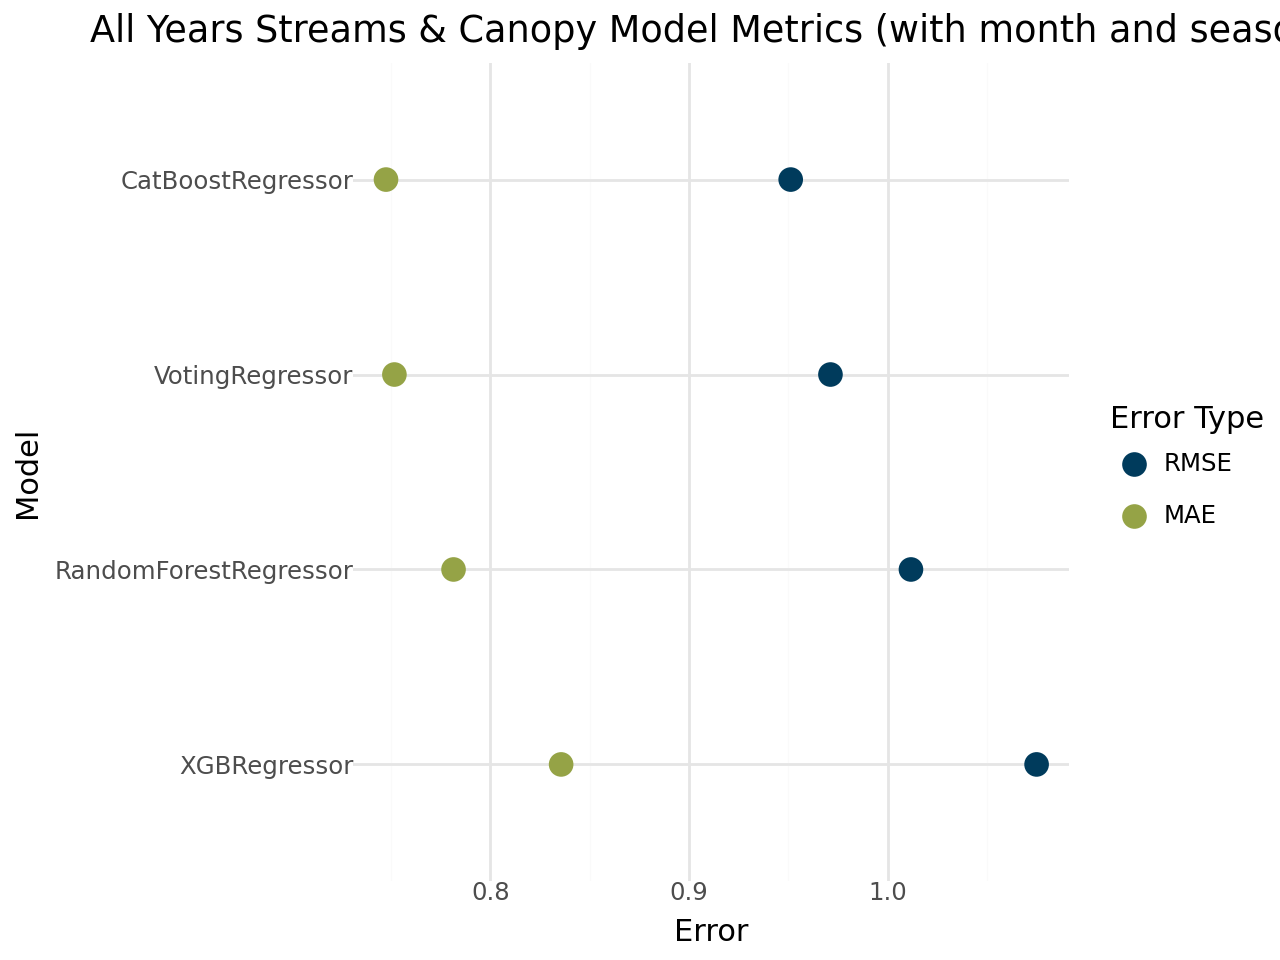

In [ ]:
dict={"Model": name_list,"RMSE":rmse_list,"MAE":mae_list,"R2":r2_list}
graphable=pd.DataFrame(dict)
long=pd.melt(graphable, id_vars=["Model"], value_vars=["RMSE", "MAE"])
order = graphable.sort_values(
    by = "RMSE", ascending = True)["Model"].tolist()
ggplot(long)+aes(x="value", y="reorder(Model, -value)",color="variable")+geom_point(size=4)+labs(x="Error",y="Model",title="All Years Streams & Canopy Model Metrics (with month and season)")+scale_color_manual(
        name="Error Type",
        breaks=["RMSE", "MAE"],
        values=["#003b5c", "#95a346"],
    )+theme_minimal()

In [ ]:
# WITHOUT MONTH_NUM AND SEASON

scaler = MinMaxScaler()
X = dfall_3[['Impervious_median','Water_median','Herbaceous_median','BareSoilDr_median','PossiblePl_median',
              'Shrub_median','UrbanTreeCanopy_pct_median']] # Deciding to use only mean (not median, max, or min) for tree canopy statistics
y = dfall_3["median_temp_c"] # Target!

feature_preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), ['Impervious_median','Water_median','Herbaceous_median','BareSoilDr_median',
                                 'PossiblePl_median','Shrub_median','UrbanTreeCanopy_pct_median'])
    ]
)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
cat = CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, verbose=0, random_seed=42)
voting_regressor = VotingRegressor(estimators=[
    ('rf', rf),
    ('xgb',xgb),
    ('cat',cat)
])

models = [rf, xgb, cat, voting_regressor]
name_list=[]
rmse_list=[]
mae_list=[]
r2_list=[]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for model in models:
    feature_pipeline = Pipeline(steps=[
        ('preprocessor', feature_preprocessor),
        ('model', model)
    ])

    full_pipeline = TransformedTargetRegressor(
        regressor=feature_pipeline,
        transformer=MinMaxScaler()
    )

    cv_results = cross_validate(
        full_pipeline, X, y, cv=kf,
        scoring=['neg_mean_squared_error', 'neg_mean_absolute_error', 'r2']
    )

    rmse_scores = np.sqrt(-cv_results['test_neg_mean_squared_error'])
    mae_scores = -cv_results['test_neg_mean_absolute_error']
    r2_scores = cv_results['test_r2']
    name_list.append(model.__class__.__name__)
    rmse_list.append(np.mean(rmse_scores))
    mae_list.append(np.mean(mae_scores))
    r2_list.append(np.mean(r2_scores))

    print(model.__class__.__name__)
    print("RMSE: ", np.mean(rmse_scores), "+/-", np.std(rmse_scores))
    print("MAE: ", np.mean(mae_scores), "+/-", np.std(mae_scores))
    print("R^2: ", np.mean(r2_scores), "+/-", np.std(r2_scores))
    print("")

RandomForestRegressor
RMSE:  4.762962861970958 +/- 0.27516721896951174
MAE:  4.1253188922273365 +/- 0.2804703954494147
R^2:  -0.11332235055445543 +/- 0.06322940413444406

XGBRegressor
RMSE:  4.774834303163802 +/- 0.2768911306962067
MAE:  4.1329704590329275 +/- 0.27186574006753983
R^2:  -0.11875852588375198 +/- 0.06161837540875719

CatBoostRegressor
RMSE:  4.773388087451733 +/- 0.27692345589651646
MAE:  4.13230646210592 +/- 0.27115899729453957
R^2:  -0.1180381103272885 +/- 0.06085772596624068

VotingRegressor
RMSE:  4.770048042543175 +/- 0.27611236963538655
MAE:  4.13019859480317 +/- 0.2744521118743952
R^2:  -0.11653312653011447 +/- 0.06163188212265804



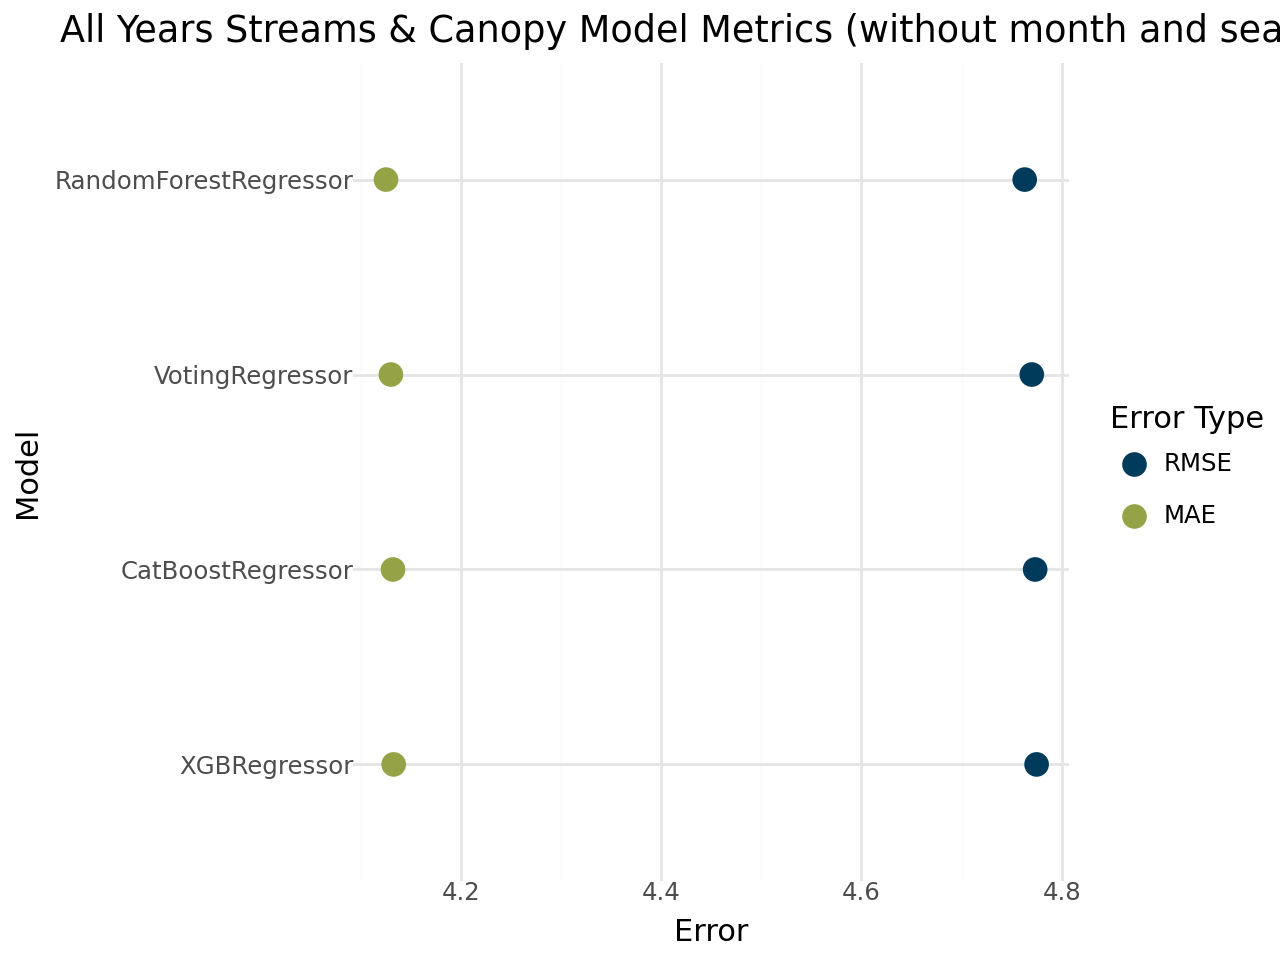

In [ ]:
dict={"Model": name_list,"RMSE":rmse_list,"MAE":mae_list,"R2":r2_list}
graphable=pd.DataFrame(dict)
long=pd.melt(graphable, id_vars=["Model"], value_vars=["RMSE", "MAE"])
order = graphable.sort_values(
    by = "RMSE", ascending = True)["Model"].tolist()
ggplot(long)+aes(x="value", y="reorder(Model, -value)",color="variable")+geom_point(size=4)+labs(x="Error",y="Model",title="All Years Streams & Canopy Model Metrics (without month and season)")+scale_color_manual(
        name="Error Type",
        breaks=["RMSE", "MAE"],
        values=["#003b5c", "#95a346"],
    )+theme_minimal()

## Tree Canopy and Weather on Stream Temperature

In [ ]:
# WITH MONTH_NUM AND SEASON

scaler = MinMaxScaler()
X = dfall_4[['month_num','season','Impervious_median','Water_median','Herbaceous_median','BareSoilDr_median','PossiblePl_median',
              'Shrub_median','UrbanTreeCanopy_pct_median', 'median_max_temp_f', 'median_precip']] # Deciding to use only mean (not median, max, or min) for tree canopy statistics
y = dfall_4["median_temp_c"] # Target!

feature_preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), ['month_num','Impervious_median','Water_median','Herbaceous_median','BareSoilDr_median',
                                 'PossiblePl_median','Shrub_median','UrbanTreeCanopy_pct_median', 'median_max_temp_f', 'median_precip']),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), ['season'])
    ]
)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
cat = CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, verbose=0, random_seed=42)
voting_regressor = VotingRegressor(estimators=[
    ('rf', rf),
    ('xgb',xgb),
    ('cat',cat)
])

models = [rf, xgb, cat, voting_regressor]
name_list=[]
rmse_list=[]
mae_list=[]
r2_list=[]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for model in models:
    feature_pipeline = Pipeline(steps=[
        ('preprocessor', feature_preprocessor),
        ('model', model)
    ])

    full_pipeline = TransformedTargetRegressor(
        regressor=feature_pipeline,
        transformer=MinMaxScaler()
    )

    cv_results = cross_validate(
        full_pipeline, X, y, cv=kf,
        scoring=['neg_mean_squared_error', 'neg_mean_absolute_error', 'r2']
    )

    rmse_scores = np.sqrt(-cv_results['test_neg_mean_squared_error'])
    mae_scores = -cv_results['test_neg_mean_absolute_error']
    r2_scores = cv_results['test_r2']
    name_list.append(model.__class__.__name__)
    rmse_list.append(np.mean(rmse_scores))
    mae_list.append(np.mean(mae_scores))
    r2_list.append(np.mean(r2_scores))

    print(model.__class__.__name__)
    print("RMSE: ", np.mean(rmse_scores), "+/-", np.std(rmse_scores))
    print("MAE: ", np.mean(mae_scores), "+/-", np.std(mae_scores))
    print("R^2: ", np.mean(r2_scores), "+/-", np.std(r2_scores))
    print("")

RandomForestRegressor
RMSE:  0.5885281868864798 +/- 0.11773759919394784
MAE:  0.4643228032127441 +/- 0.09023318236084917
R^2:  0.9818725323466886 +/- 0.004321165105719801

XGBRegressor
RMSE:  0.4895654523314379 +/- 0.10970593972359965
MAE:  0.3768546598641454 +/- 0.07516196933678548
R^2:  0.9873822234218672 +/- 0.0035451677553592865

CatBoostRegressor
RMSE:  0.7354511140077171 +/- 0.16360167278632937
MAE:  0.6111482533047047 +/- 0.14295312064523963
R^2:  0.9705830226175826 +/- 0.010522285497329097

VotingRegressor
RMSE:  0.522277472598548 +/- 0.12614632696633002
MAE:  0.41090779297487867 +/- 0.0974903641295484
R^2:  0.9852076572662625 +/- 0.005320739261440711



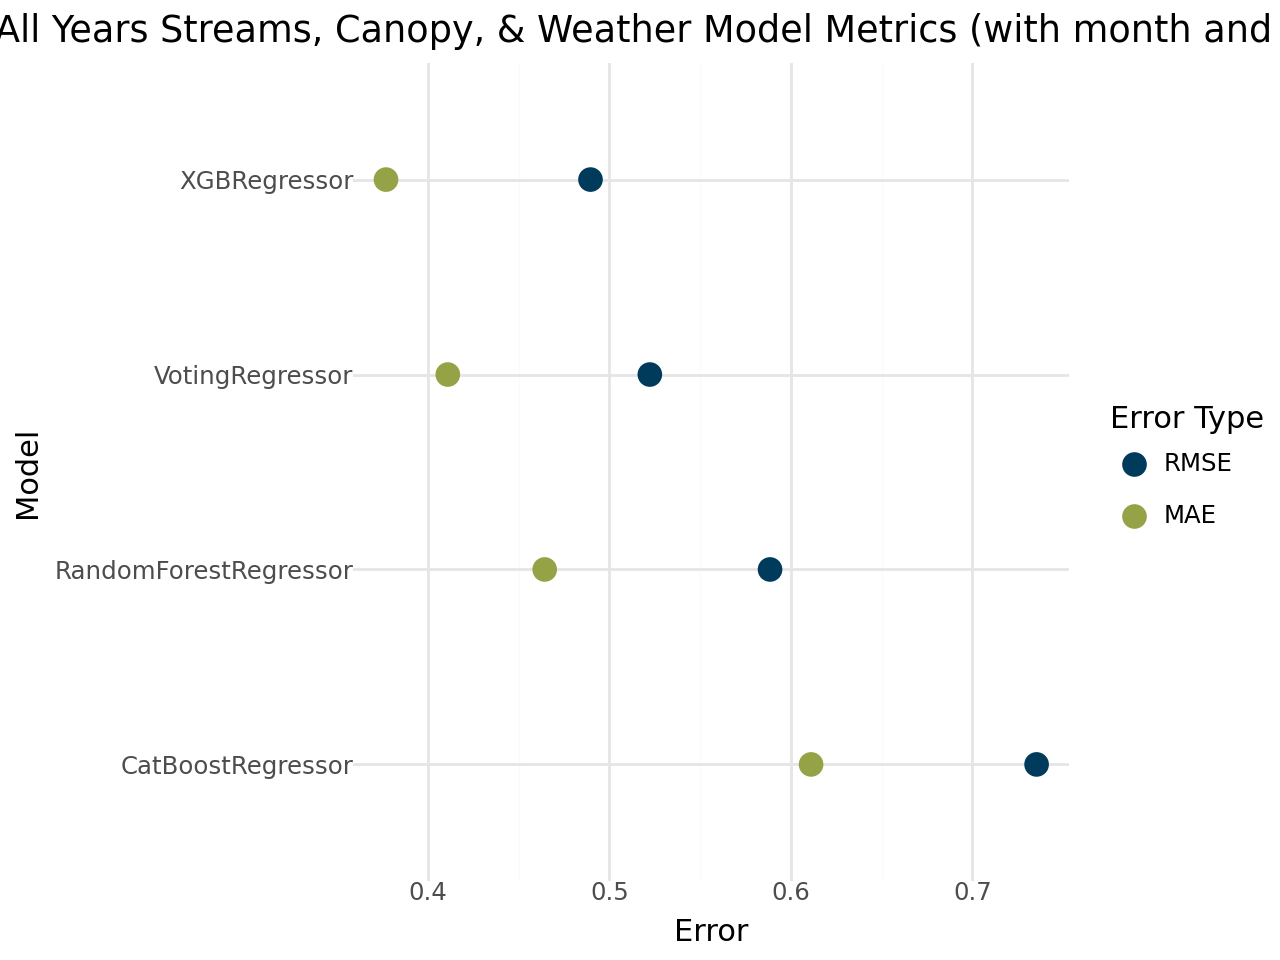

In [ ]:
dict={"Model": name_list,"RMSE":rmse_list,"MAE":mae_list,"R2":r2_list}
graphable=pd.DataFrame(dict)
long=pd.melt(graphable, id_vars=["Model"], value_vars=["RMSE", "MAE"])
order = graphable.sort_values(
    by = "RMSE", ascending = True)["Model"].tolist()
ggplot(long)+aes(x="value", y="reorder(Model, -value)",color="variable")+geom_point(size=4)+labs(x="Error",y="Model",title="All Years Streams, Canopy, & Weather Model Metrics (with month and season)")+scale_color_manual(
        name="Error Type",
        breaks=["RMSE", "MAE"],
        values=["#003b5c", "#95a346"],
    )+theme_minimal()

In [ ]:
# WITHOUT MONTH_NUM AND SEASON

scaler = MinMaxScaler()
X = dfall_4[['Impervious_median','Water_median','Herbaceous_median','BareSoilDr_median','PossiblePl_median',
              'Shrub_median','UrbanTreeCanopy_pct_median', 'median_max_temp_f', 'median_precip']] # Deciding to use only mean (not median, max, or min) for tree canopy statistics
y = dfall_4["median_temp_c"] # Target!

feature_preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), ['Impervious_median','Water_median','Herbaceous_median','BareSoilDr_median',
                                 'PossiblePl_median','Shrub_median','UrbanTreeCanopy_pct_median', 'median_max_temp_f', 'median_precip'])
    ]
)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
cat = CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, verbose=0, random_seed=42)
voting_regressor = VotingRegressor(estimators=[
    ('rf', rf),
    ('xgb',xgb),
    ('cat',cat)
])

models = [rf, xgb, cat, voting_regressor]
name_list=[]
rmse_list=[]
mae_list=[]
r2_list=[]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for model in models:
    feature_pipeline = Pipeline(steps=[
        ('preprocessor', feature_preprocessor),
        ('model', model)
    ])

    full_pipeline = TransformedTargetRegressor(
        regressor=feature_pipeline,
        transformer=MinMaxScaler()
    )

    cv_results = cross_validate(
        full_pipeline, X, y, cv=kf,
        scoring=['neg_mean_squared_error', 'neg_mean_absolute_error', 'r2']
    )

    rmse_scores = np.sqrt(-cv_results['test_neg_mean_squared_error'])
    mae_scores = -cv_results['test_neg_mean_absolute_error']
    r2_scores = cv_results['test_r2']
    name_list.append(model.__class__.__name__)
    rmse_list.append(np.mean(rmse_scores))
    mae_list.append(np.mean(mae_scores))
    r2_list.append(np.mean(r2_scores))

    print(model.__class__.__name__)
    print("RMSE: ", np.mean(rmse_scores), "+/-", np.std(rmse_scores))
    print("MAE: ", np.mean(mae_scores), "+/-", np.std(mae_scores))
    print("R^2: ", np.mean(r2_scores), "+/-", np.std(r2_scores))
    print("")

RandomForestRegressor
RMSE:  0.9123892264240695 +/- 0.2776782483293535
MAE:  0.6541197237991285 +/- 0.16741112778497189
R^2:  0.9553523308332037 +/- 0.0171512033423398

XGBRegressor
RMSE:  0.9358748363370364 +/- 0.2763571713351714
MAE:  0.6430300993156403 +/- 0.16136316491986813
R^2:  0.9511681449800239 +/- 0.020711520985944355

CatBoostRegressor
RMSE:  1.0360306736507883 +/- 0.3060113727803788
MAE:  0.8258172187930299 +/- 0.23255606326707873
R^2:  0.9416144327351581 +/- 0.02240407702077034

VotingRegressor
RMSE:  0.900999218383365 +/- 0.2866294147742209
MAE:  0.6597059921242525 +/- 0.17802874941746713
R^2:  0.9554378519152994 +/- 0.018185083007650853



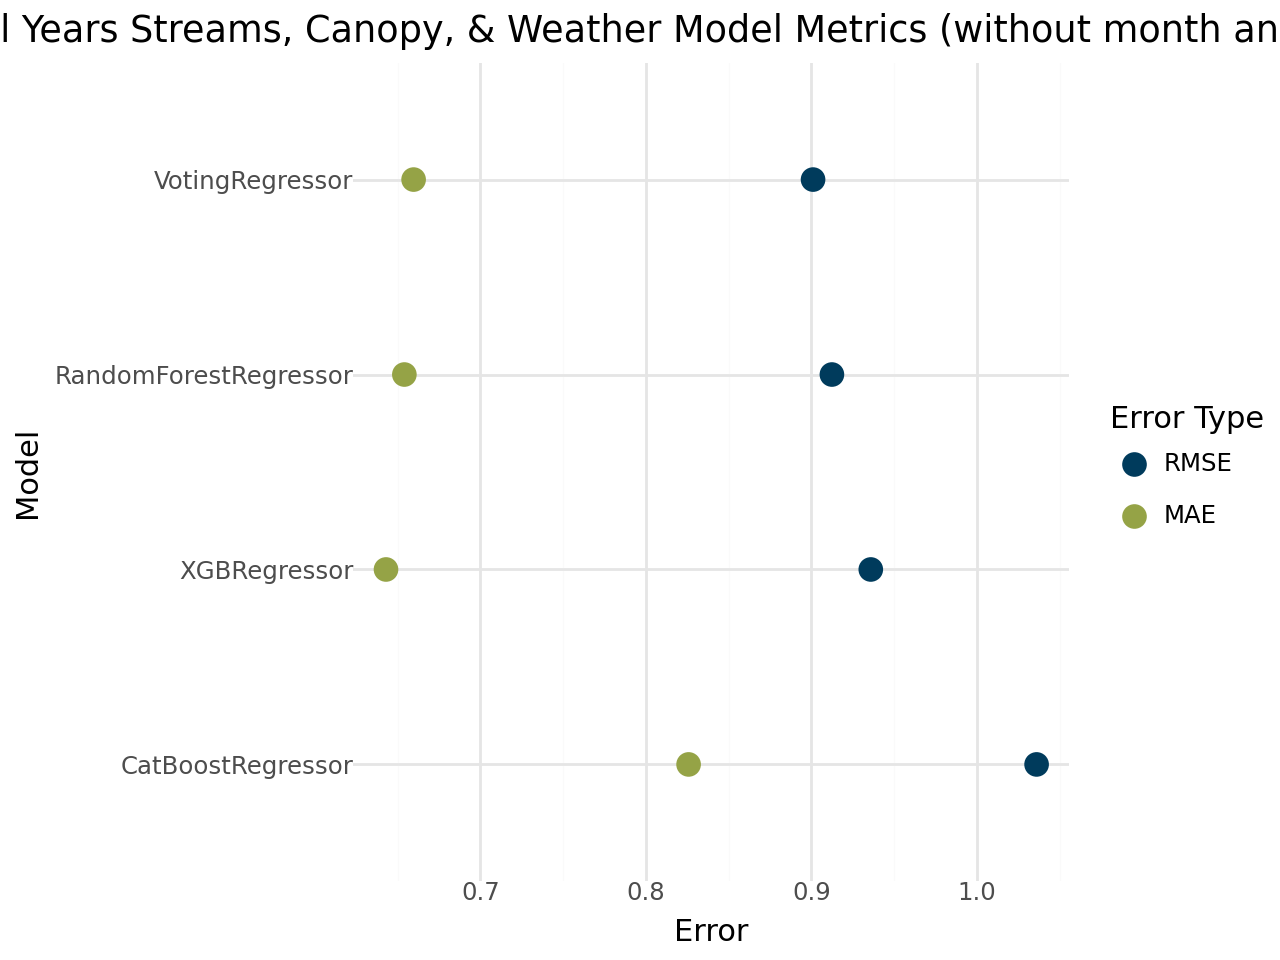

In [ ]:
dict={"Model": name_list,"RMSE":rmse_list,"MAE":mae_list,"R2":r2_list}
graphable=pd.DataFrame(dict)
long=pd.melt(graphable, id_vars=["Model"], value_vars=["RMSE", "MAE"])
order = graphable.sort_values(
    by = "RMSE", ascending = True)["Model"].tolist()
ggplot(long)+aes(x="value", y="reorder(Model, -value)",color="variable")+geom_point(size=4)+labs(x="Error",y="Model",title="All Years Streams, Canopy, & Weather Model Metrics (without month and season)")+scale_color_manual(
        name="Error Type",
        breaks=["RMSE", "MAE"],
        values=["#003b5c", "#95a346"],
    )+theme_minimal()

## Feature Importance

From the above tests, we can determine feature importance already. We know that tree canopy does not have any significant impact and weather has basically too much impact and practicly predicts the stream temperature itself.

If we want to look at the feature importance of one model, then we must use a different pipeline. We must use a different pipeline because we used cross-validation, which created 5 models with the 5-folds. To look at what the feature importance function gives us, we must train one model without cross-validation.

Consider this limitation when looking at these results. However, despite the different pipeline without cross-validation, we can see that the results of the feature importance function show similarly to what we would expect from our findings from analyzing all our previous models.

Note:
* The RandomFoest model was chosen for this because it performed compartively well across all models.
* RandomForest's default metric for feature importance is mean decrease in impurity (MDI).

                           feature  importance
7           num__median_max_temp_f    0.984286
6  num__UrbanTreeCanopy_pct_median    0.007314
8               num__median_precip    0.006640
5                num__Shrub_median    0.000481
2           num__Herbaceous_median    0.000370
0           num__Impervious_median    0.000274
3           num__BareSoilDr_median    0.000239
4           num__PossiblePl_median    0.000211
1                num__Water_median    0.000185


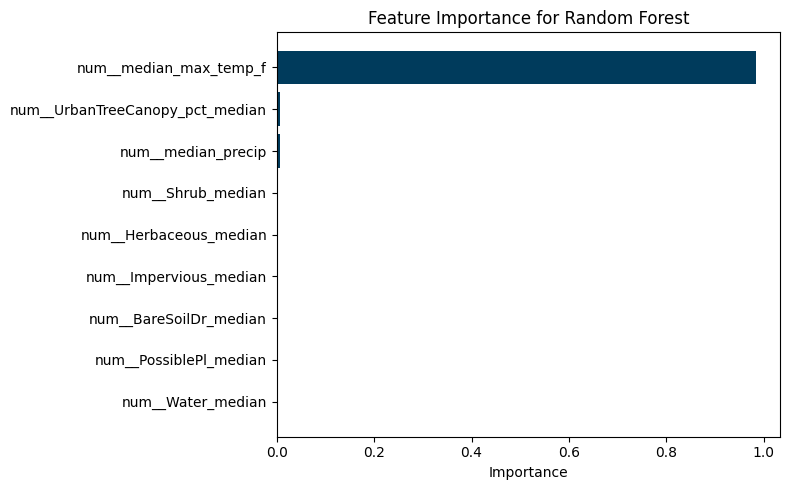

In [ ]:
# FEATURE IMPORTANCE ON RANDOM FOREST

rf_pipeline = Pipeline(steps=[
    ('preprocessor', feature_preprocessor),
    ('model', rf)
])

full_rf_pipeline = TransformedTargetRegressor(
    regressor=rf_pipeline,
    transformer=MinMaxScaler()
)

full_rf_pipeline.fit(X, y)

feature_names = full_rf_pipeline.regressor_.named_steps['preprocessor'].get_feature_names_out()
fitted_rf = full_rf_pipeline.regressor_.named_steps['model']

importances = pd.DataFrame({
    'feature': feature_names,
    'importance': fitted_rf.feature_importances_
}).sort_values('importance', ascending=False)

print(importances)

plt.figure(figsize=(8, 5))
plt.barh(importances['feature'], importances['importance'], color='#003b5c')
plt.xlabel('Importance')
plt.title('Feature Importance for Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()